In [1]:
pip install -U pymoo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 328.3/328.3 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 3.9 MB/s eta 0:00:00


Final Objective Values:
[[-5635.97675409   526.39463863]
 [-4762.02379146   304.0338758 ]
 [-5631.25980301   519.82034636]
 ...
 [-5583.19080432   450.75690934]
 [-4983.41595923   318.79714089]
 [-5042.86895527   324.38129311]]

Final Decision Variables:
[[2.5        2.54042693 2.75841765 ... 2.9067544  2.6989927  2.50000179]
 [2.65471406 2.65471756 2.84238971 ... 2.66767937 2.65478528 2.85378438]
 [2.5000001  2.540413   2.75839099 ... 2.88480398 2.69234447 2.50000687]
 ...
 [2.50000001 2.5404129  2.75840286 ... 2.72761026 2.53137152 2.50000172]
 [2.65471521 2.65471931 2.65531884 ... 2.66767549 2.65478282 2.85374967]
 [2.65471362 2.65472287 2.65512799 ... 2.66768805 2.65481367 2.85378078]]

Best Solution:
Objective Values (Weighted Milk Production, Weighted Conception DIM):
[-5562.0954752    420.89258276]
Decision Variables:
[2.5        2.50000092 2.71799874 2.50000126 2.64868021 2.90766578
 3.15366353 2.90068737 2.66797921 2.50019065 2.50000683]

Worst Solution:
Objective Values (Weig

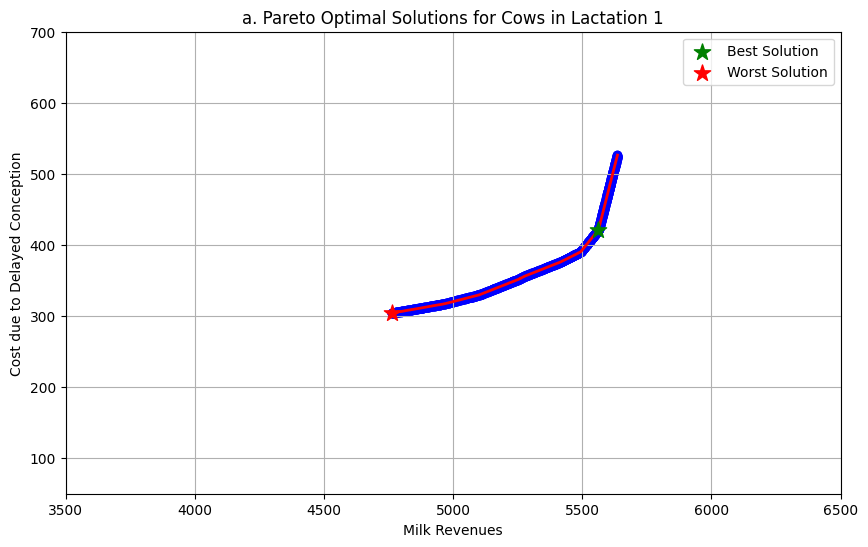

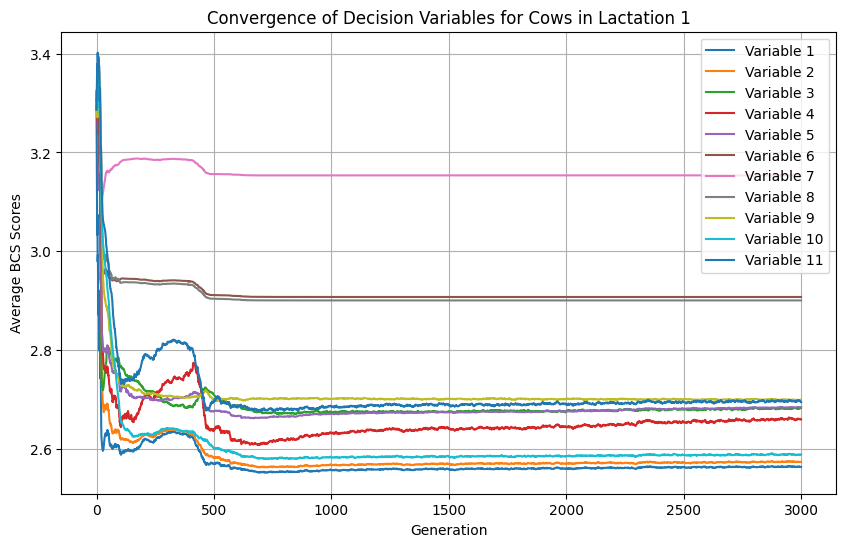

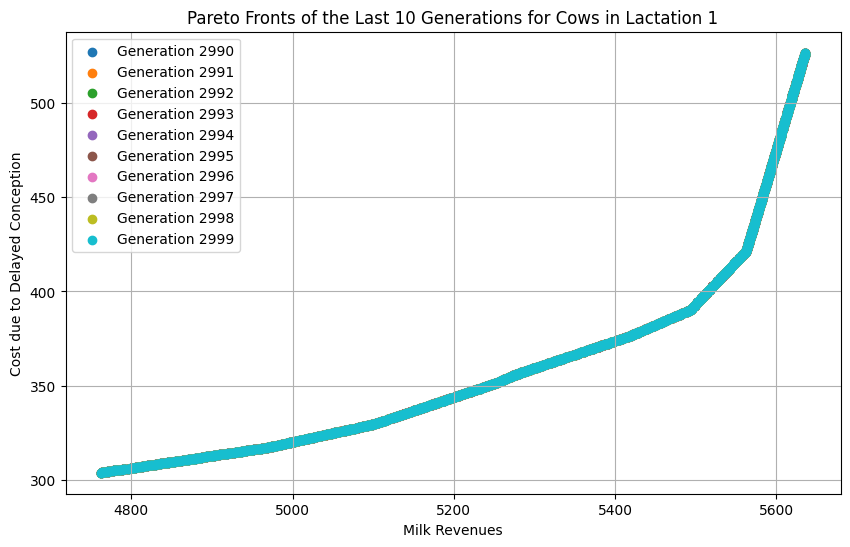

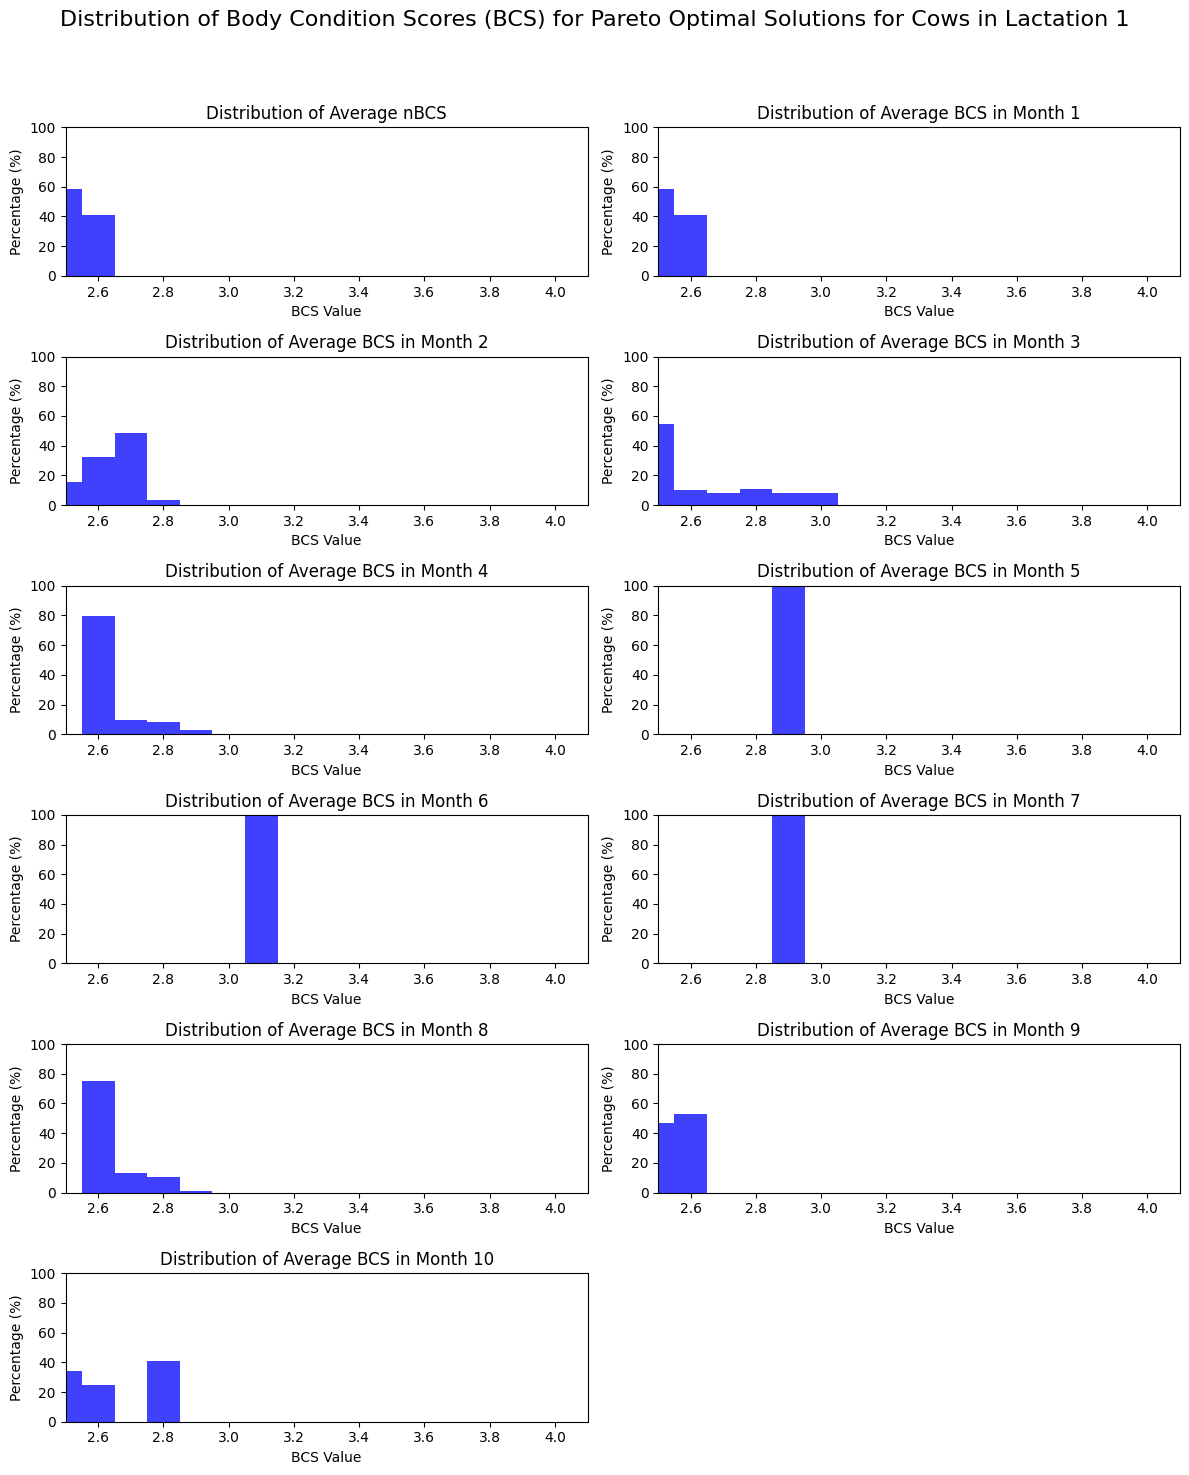

In [2]:
# Lactation1
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt

# Define the custom problem
class CustomProblem(Problem):

    def __init__(self, weights_conception_DIM):
        super().__init__(n_var=11, n_obj=2, n_constr=0, xl=2.5, xu=4.1)
        self.weights_conception_DIM = weights_conception_DIM

    def calculate_weighted_conception_DIM(self, conception_DIM):
        weights = self.weights_conception_DIM
        weighted_conception_DIM = 0
        days_remaining = conception_DIM
        for i in range(10):
            if days_remaining > 30:
                weighted_conception_DIM += 30 * weights[i]
                days_remaining -= 30
            else:
                weighted_conception_DIM += days_remaining * weights[i]
                break
        return weighted_conception_DIM

    def _evaluate(self, X, out, *args, **kwargs):
        F1 = []
        F2 = []

        for x in X:
            penalty = 0

            # Existing penalty checks
            for i in range(9):
                if abs(x[1] - x[2]) >= 0.218:
                    penalty += 100000
                if abs(x[2] - x[3]) >= 0.259:
                    penalty += 100000
                if abs(x[3] - x[4]) >= 0.165:
                    penalty += 100000
                if abs(x[4] - x[5]) >= 0.259:
                    penalty += 100000
                if abs(x[5] - x[6]) >= 0.246:
                    penalty += 100000
                if abs(x[6] - x[7]) >= 0.253:
                    penalty += 100000
                if abs(x[7] - x[8]) >= 0.233:
                    penalty += 100000
                if abs(x[8] - x[9]) >= 0.208:
                    penalty += 100000
                if abs(x[9] - x[10]) >= 0.199:
                    penalty += 100000

            # NEW: Ensure x[0] is the minimum among all x[i].
            for i2 in range(1, 11):
                if x[0] > x[i2]:
                    penalty += 100000

            milk_production = (23630.34 - 139.74 * x[0] - 457.98 * x[1] + 870.06 * x[2]
                   - 2333.76 * x[3] - 1238.28 * x[4] - 948.60 * x[5]
                   + 2088.96 * x[6] - 1767.66 * x[7] + 439.62 * x[8]
                   + 317.22 * x[9] - 859.86 * x[10])

            conception_DIM = (155 - 77.0 * x[0] + 43.7 * x[1] + 14.3 * x[2]
                              - 30.0 * x[3] + 0.19 * x[4] + 14.6 * x[5]
                              - 25.7 * x[6] - 23.8 * x[7] + 59.5 * x[8]
                              + 48.1 * x[9] - 34.7 * x[10])

            # Apply penalties
            milk_production -= penalty
            conception_DIM += penalty

            weighted_milk_production = -0.40 * milk_production
            weighted_conception_DIM = self.calculate_weighted_conception_DIM(conception_DIM)

            F1.append(weighted_milk_production)
            F2.append(weighted_conception_DIM)

        out["F"] = np.column_stack([F1, F2])


# Weights for 10 months
weights_conception_DIM = [1.39, 3.34, 4.73, 4.47, 4.04, 3.62, 3.17, 2.67, 2.21, 1.72]
problem = CustomProblem(weights_conception_DIM)

# Set up the NSGA-II algorithm
algorithm = NSGA2(pop_size=1000)

# Callback to store results
class GenerationCallback:

    def __init__(self):
        self.generations = []
        self.decision_vars = []

    def __call__(self, algorithm):
        self.generations.append(algorithm.pop.get("F"))
        self.decision_vars.append(algorithm.pop.get("X"))

# Initialize callback
callback = GenerationCallback()

# Run the optimization
res = minimize(problem,
               algorithm,
               ('n_gen', 3000),  # Increased number of generations
               seed=204,
               callback=callback,
               verbose=False)

# Final results
print("Final Objective Values:")
print(res.F)
print()

print("Final Decision Variables:")
print(res.X)
print()

# Find the best solution from the last generation
last_gen = callback.generations[-1]
last_gen_decision_vars = callback.decision_vars[-1]

# Change weighted milk production to positive and subtract weighted conception DIM
objective_values = -last_gen[:, 0] - last_gen[:, 1]
best_index = np.argmax(objective_values)
best_solution = last_gen[best_index]
best_decision_vars = last_gen_decision_vars[best_index]

print("Best Solution:")
print("Objective Values (Weighted Milk Production, Weighted Conception DIM):")
print(best_solution)
print("Decision Variables:")
print(best_decision_vars)
print()

# Find the worst solution from the last generation
worst_index = np.argmin(objective_values)
worst_solution = last_gen[worst_index]
worst_decision_vars = last_gen_decision_vars[worst_index]

print("Worst Solution:")
print("Objective Values (Weighted Milk Production, Weighted Conception DIM):")
print(worst_solution)
print("Decision Variables:")
print(worst_decision_vars)
print()

# Plot Pareto front with line, highlighting best and worst solutions
plt.figure(figsize=(10, 6))

# Plot all Pareto front solutions with a red line
pareto_front = res.F[np.argsort(res.F[:, 0])]
plt.plot(-pareto_front[:, 0], pareto_front[:, 1], 'r-', lw=2)  # Changed sign for plotting

# Plot all solutions in blue
plt.scatter(-pareto_front[:, 0], pareto_front[:, 1], c='blue', marker='o')  # Changed sign for plotting

# Highlight the best solution with a green star (plotted after the blue points)
plt.scatter(-best_solution[0], best_solution[1], c='green', marker='*', s=150, label="Best Solution", zorder=5)

# Highlight the worst solution with a red star (plotted after the blue points)
plt.scatter(-worst_solution[0], worst_solution[1], c='red', marker='*', s=150, label="Worst Solution", zorder=5)

# Set axis limits
plt.xlim(3500, 6500)
plt.ylim(50, 700)

plt.title('a. Pareto Optimal Solutions for Cows in Lactation 1')
plt.xlabel('Milk Revenues')
plt.ylabel('Cost due to Delayed Conception')
plt.legend()
plt.grid(True)
plt.show()

# Plot convergence of decision variables
average_decision_vars = np.array([np.mean(gen, axis=0) for gen in callback.decision_vars])

plt.figure(figsize=(10, 6))
for i in range(problem.n_var):
    plt.plot(average_decision_vars[:, i], label=f'Variable {i+1}')
plt.title('Convergence of Decision Variables for Cows in Lactation 1')
plt.xlabel('Generation')
plt.ylabel('Average BCS Scores')
plt.legend()
plt.grid(True)
plt.show()

# Plot Pareto fronts of the last 10 generations
last_10_generations = callback.generations[-10:]
plt.figure(figsize=(10, 6))
for i, gen in enumerate(last_10_generations):
    plt.scatter(-gen[:, 0], gen[:, 1], label=f'Generation {len(callback.generations) - 10 + i}')
plt.title('Pareto Fronts of the Last 10 Generations for Cows in Lactation 1')
plt.xlabel('Milk Revenues')
plt.ylabel('Cost due to Delayed Conception')
plt.legend()
plt.grid(True)
plt.show()

# Plot histogram of Pareto optimal solutions with percentage on y-axis
pareto_solutions = res.X  # These are the decision variables of the Pareto front solutions
n_vars = problem.n_var

# Define the bin size
bin_width = 0.1
bins = np.arange(2.5, 4.1 + bin_width, bin_width)  # Set bins from 2.5 to 4.1 with 0.1 intervals

# Plot histograms of Pareto optimal solutions for each decision variable
plt.figure(figsize=(12, 15))

for i in range(n_vars):
    plt.subplot(6, 2, i + 1)  # Create subplots in a 5x2 grid

    # Create histogram data
    counts, bins = np.histogram(pareto_solutions[:, i], bins=bins, density=True)

    # Convert to percentage by multiplying by 100
    percentages = counts * np.diff(bins)[0] * 100

    plt.bar(bins[:-1], percentages, width=bin_width, alpha=0.75, color='blue')

    plt.ylim(0, 100)
    plt.xlim(2.5, 4.1)
    if i == 0:
        plt.title("Distribution of Average nBCS")
    else:
        plt.title(f"Distribution of Average BCS in Month {i}")
    plt.xlabel('BCS Value')
    plt.ylabel('Percentage (%)')

plt.suptitle(
    'Distribution of Body Condition Scores (BCS) for Pareto Optimal Solutions for Cows in Lactation 1',
    fontsize=16
)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


Final Objective Values:
[[-6009.53664854   466.44520176]
 [-5076.24316105   284.87945149]
 [-5261.08890742   298.91116094]
 ...
 [-5387.15418621   306.71832332]
 [-5997.24303532   452.02051195]
 [-5654.02035983   343.99831218]]

Final Decision Variables:
[[2.50000044 2.5779812  2.83784097 ... 2.7504639  2.77521723 2.55427923]
 [2.67961542 2.67962457 2.67988781 ... 2.90363361 2.67965916 2.90064006]
 [2.60438287 2.60439557 2.70008273 ... 2.82894833 2.60500685 2.82595263]
 ...
 [2.50673631 2.50680023 2.60451821 ... 2.73069622 2.50676151 2.72748983]
 [2.50002033 2.57725274 2.83719223 ... 2.75004426 2.70134578 2.50008703]
 [2.50673862 2.50677698 2.76677052 ... 2.73075036 2.50680381 2.7273549 ]]

Best Solution:
Objective Values: [-6005.11474907   456.80447118]
Decision Variables: [2.50000371 2.57725416 2.8372476  2.52930083 2.50646237 2.77638221
 2.5244038  2.50051888 2.75049374 2.72069573 2.50011619]

Worst Solution:
Objective Values: [-5076.24316105   284.87945149]
Decision Variables: [2.6

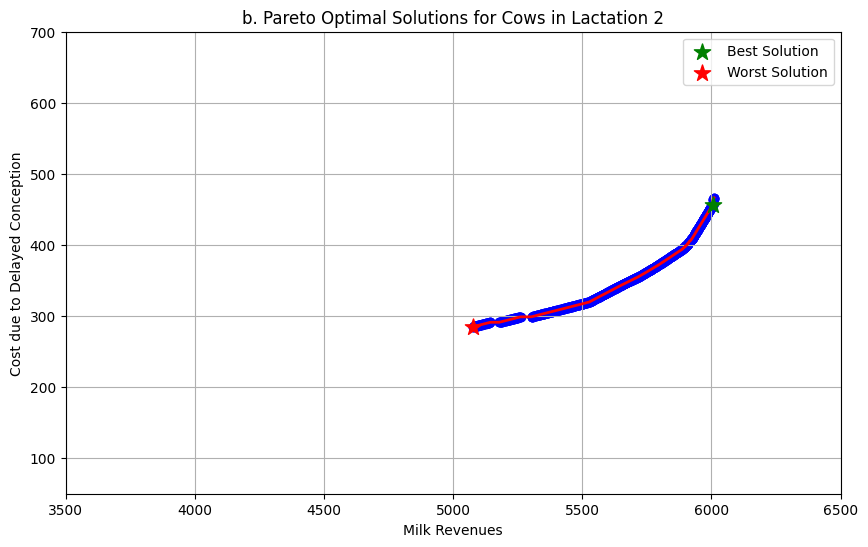

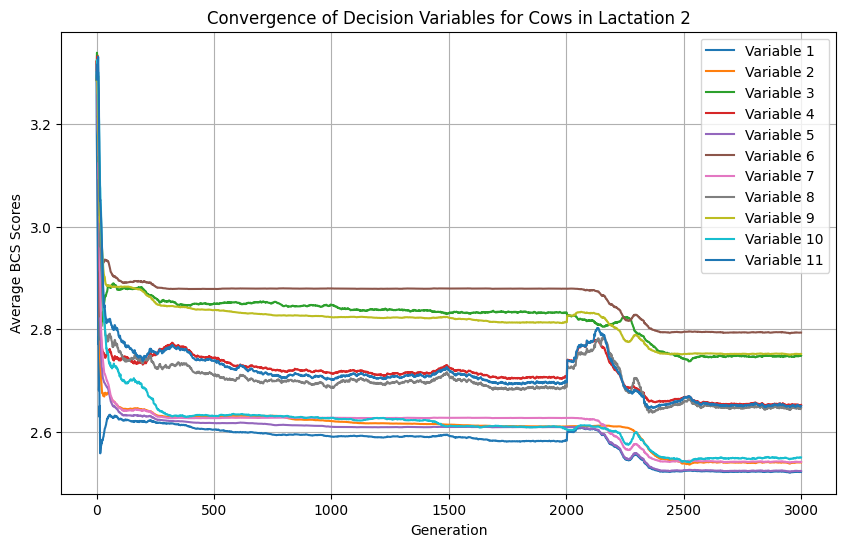

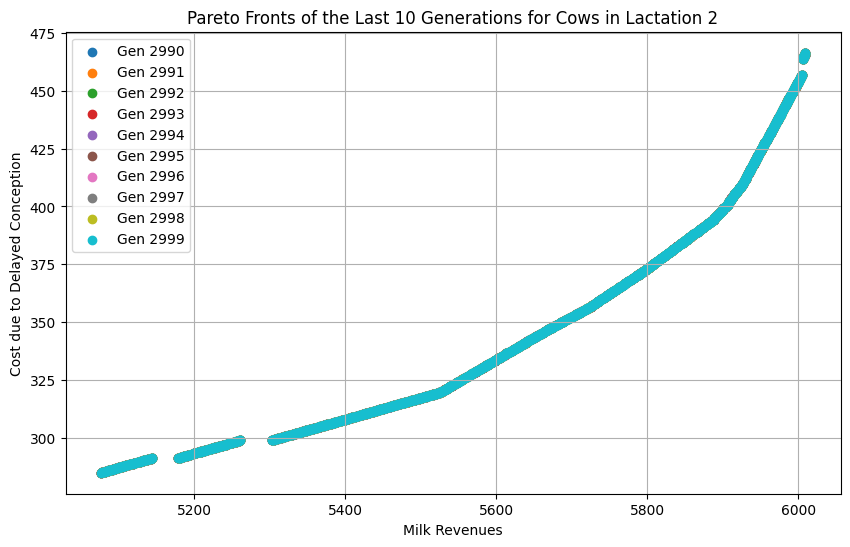

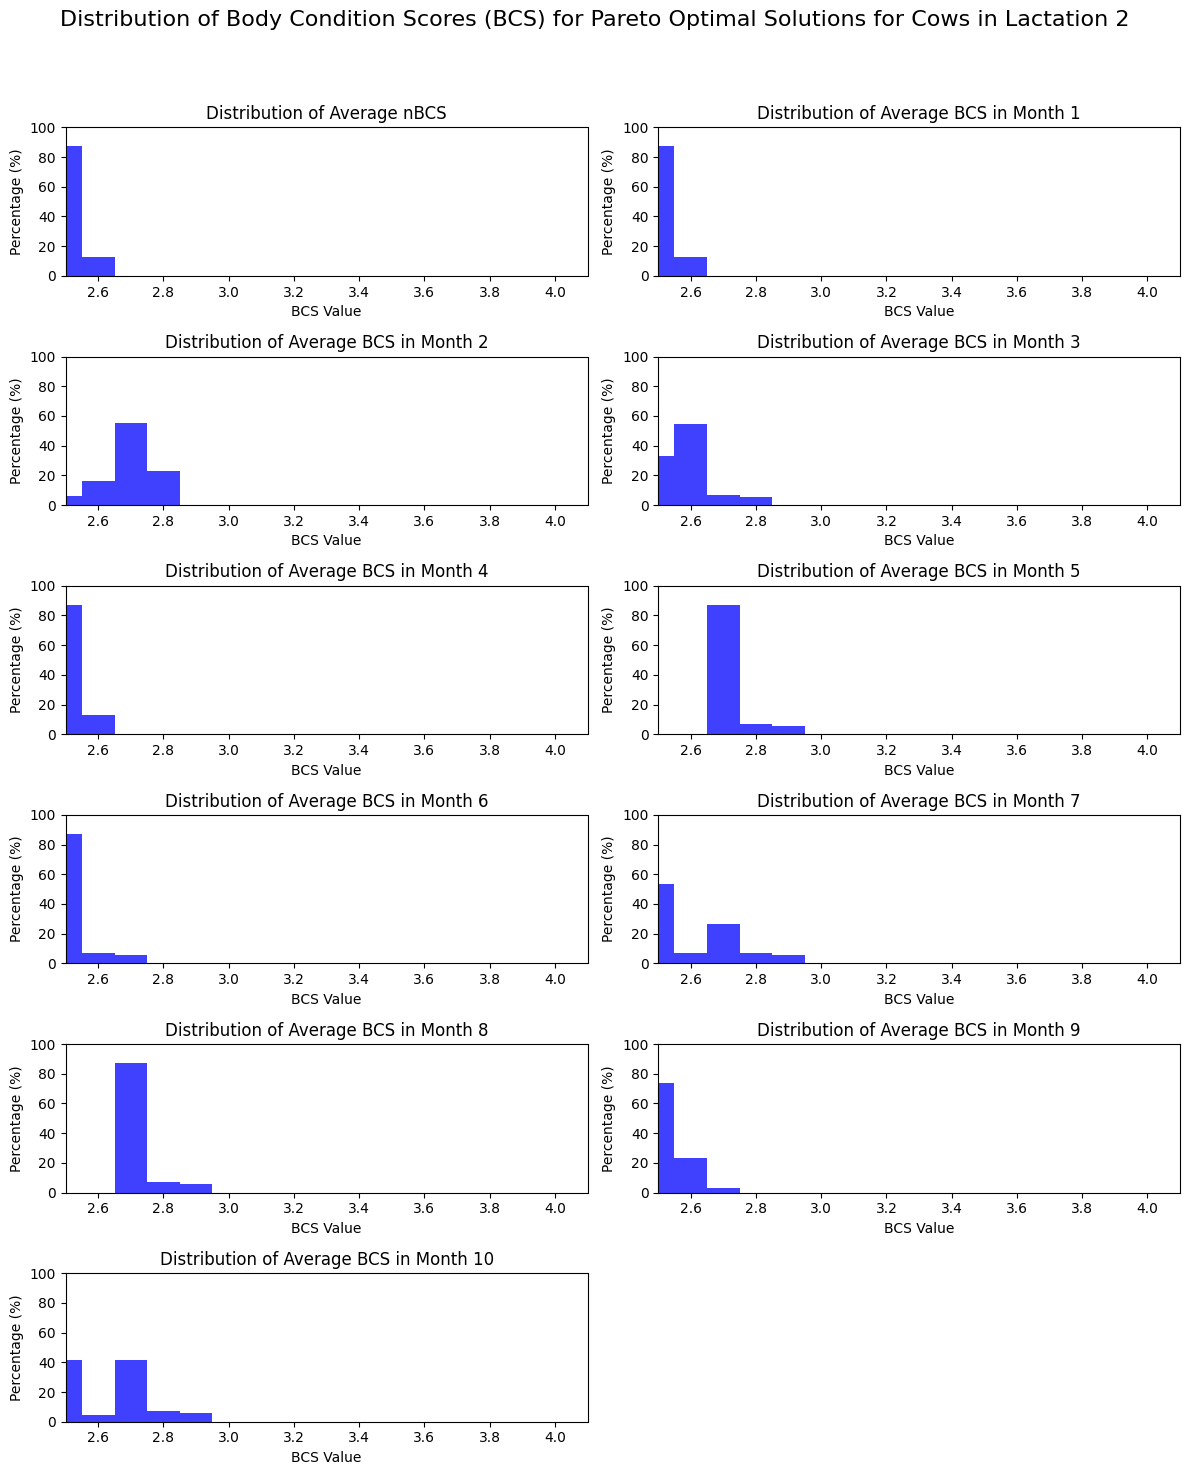

In [3]:
# Lactation 2
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt

# Define the custom problem
class CustomProblem(Problem):

    def __init__(self, weights_conception_DIM):
        super().__init__(n_var=11, n_obj=2, n_constr=0, xl=2.5, xu=4.1)
        self.weights_conception_DIM = weights_conception_DIM

    def calculate_weighted_conception_DIM(self, conception_DIM):
        weights = self.weights_conception_DIM
        weighted_conception_DIM = 0
        days_remaining = conception_DIM
        for i in range(10):
            if days_remaining > 30:
                weighted_conception_DIM += 30 * weights[i]
                days_remaining -= 30
            else:
                weighted_conception_DIM += days_remaining * weights[i]
                break
        return weighted_conception_DIM

    def _evaluate(self, X, out, *args, **kwargs):
        F1 = []
        F2 = []

        for x in X:
            penalty = 0
            for i in range(9):
                if abs(x[1] - x[2]) >= 0.260:
                    penalty += 100000
                if abs(x[2] - x[3]) >= 0.308:
                    penalty += 100000
                if abs(x[3] - x[4]) >= 0.183:
                    penalty += 100000
                if abs(x[4] - x[5]) >= 0.270:
                    penalty += 100000
                if abs(x[5] - x[6]) >= 0.252:
                    penalty += 100000
                if abs(x[6] - x[7]) >= 0.272:
                    penalty += 100000
                if abs(x[7] - x[8]) >= 0.250:
                    penalty += 100000
                if abs(x[8] - x[9]) >= 0.224:
                    penalty += 100000
                if abs(x[9] - x[10]) >= 0.221:
                    penalty += 100000

            # NEW: Ensure x[0] is the minimum among all x[i]
            for i2 in range(1, 11):
                if x[0] > x[i2]:
                    penalty += 100000

            milk_production = (21770.88 - 574.26 * x[0] - 1157.70 * x[1] + 2138.94 * x[2]
                   - 1237.26 * x[3] - 1459.62 * x[4] + 1094.46 * x[5]
                   - 942.48 * x[6] - 1704.42 * x[7] + 455.94 * x[8]
                   + 1038.36 * x[9] - 838.44 * x[10])

            conception_DIM = (145 - 62.2 * x[0] + 11.5 * x[1] + 15.5 * x[2]
                              - 25.2 * x[3] + 25.9 * x[4] - 39.5 * x[5]
                              + 47.8 * x[6] - 25.3 * x[7] - 1.16 * x[8]
                              + 52.6 * x[9] - 15.4 * x[10])

            # Apply penalties
            milk_production -= penalty
            conception_DIM += penalty

            weighted_milk_production = -0.40 * milk_production
            weighted_conception_DIM = self.calculate_weighted_conception_DIM(conception_DIM)

            F1.append(weighted_milk_production)
            F2.append(weighted_conception_DIM)

        out["F"] = np.column_stack([F1, F2])

# Weights for 10 months
weights_conception_DIM = [2.40, 4.00, 5.13, 4.73, 4.23, 3.77, 3.27, 2.70, 2.20, 1.67]
problem = CustomProblem(weights_conception_DIM)

# Set up the NSGA-II algorithm
algorithm = NSGA2(pop_size=1000)

# Callback to store results
class GenerationCallback:
    def __init__(self):
        self.generations = []
        self.decision_vars = []

    def __call__(self, algorithm):
        self.generations.append(algorithm.pop.get("F"))
        self.decision_vars.append(algorithm.pop.get("X"))

callback = GenerationCallback()

# Run the optimization
res = minimize(problem,
               algorithm,
               ('n_gen', 3000),
               seed=204,
               callback=callback,
               verbose=False)

# Results
print("Final Objective Values:")
print(res.F)
print("\nFinal Decision Variables:")
print(res.X)

# Best and Worst Solutions
last_gen = callback.generations[-1]
last_gen_decision_vars = callback.decision_vars[-1]
objective_values = -last_gen[:, 0] - last_gen[:, 1]
best_index = np.argmax(objective_values)
worst_index = np.argmin(objective_values)

best_solution = last_gen[best_index]
best_decision_vars = last_gen_decision_vars[best_index]
worst_solution = last_gen[worst_index]
worst_decision_vars = last_gen_decision_vars[worst_index]

print("\nBest Solution:")
print("Objective Values:", best_solution)
print("Decision Variables:", best_decision_vars)
print("\nWorst Solution:")
print("Objective Values:", worst_solution)
print("Decision Variables:", worst_decision_vars)

# Plot Pareto Front
plt.figure(figsize=(10, 6))
pareto_front = res.F[np.argsort(res.F[:, 0])]
plt.plot(-pareto_front[:, 0], pareto_front[:, 1], 'r-', lw=2)
plt.scatter(-pareto_front[:, 0], pareto_front[:, 1], c='blue', marker='o')
plt.scatter(-best_solution[0], best_solution[1], c='green', marker='*', s=150, label="Best Solution", zorder=5)
plt.scatter(-worst_solution[0], worst_solution[1], c='red', marker='*', s=150, label="Worst Solution", zorder=5)
plt.xlim(3500, 6500)
plt.ylim(50, 700)
plt.title('b. Pareto Optimal Solutions for Cows in Lactation 2')
plt.xlabel('Milk Revenues')
plt.ylabel('Cost due to Delayed Conception')
plt.legend()
plt.grid(True)
plt.show()

# Plot Decision Variable Convergence
average_decision_vars = np.array([np.mean(gen, axis=0) for gen in callback.decision_vars])
plt.figure(figsize=(10, 6))
for i in range(problem.n_var):
    plt.plot(average_decision_vars[:, i], label=f'Variable {i+1}')
plt.title('Convergence of Decision Variables for Cows in Lactation 2')
plt.xlabel('Generation')
plt.ylabel('Average BCS Scores')
plt.legend()
plt.grid(True)
plt.show()

# Plot Last 10 Generations
last_10_generations = callback.generations[-10:]
plt.figure(figsize=(10, 6))
for i, gen in enumerate(last_10_generations):
    plt.scatter(-gen[:, 0], gen[:, 1], label=f'Gen {len(callback.generations) - 10 + i}')
plt.title('Pareto Fronts of the Last 10 Generations for Cows in Lactation 2')
plt.xlabel('Milk Revenues')
plt.ylabel('Cost due to Delayed Conception')
plt.legend()
plt.grid(True)
plt.show()

# Plot Histograms of Decision Variables
pareto_solutions = res.X
bin_width = 0.1
bins = np.arange(2.5, 4.1 + bin_width, bin_width)
plt.figure(figsize=(12, 15))
for i in range(problem.n_var):
    plt.subplot(6, 2, i + 1)
    counts, bins = np.histogram(pareto_solutions[:, i], bins=bins, density=True)
    percentages = counts * np.diff(bins)[0] * 100
    plt.bar(bins[:-1], percentages, width=bin_width, alpha=0.75, color='blue')
    plt.ylim(0, 100)
    plt.xlim(2.5, 4.1)
    plt.title(f"Distribution of Average BCS in Month {i}" if i > 0 else "Distribution of Average nBCS")
    plt.xlabel('BCS Value')
    plt.ylabel('Percentage (%)')
plt.suptitle('Distribution of Body Condition Scores (BCS) for Pareto Optimal Solutions for Cows in Lactation 2', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


Final Objective Values:
[[-4716.5559297    260.25581076]
 [-5997.53755505   661.36341266]
 [-4861.70542661   284.4957062 ]
 ...
 [-5721.81750938   428.52800001]
 [-5668.08995701   413.71486533]
 [-5640.37554592   406.21562677]]

Final Decision Variables:
[[2.91138453 2.91209111 2.91145952 ... 2.91140349 2.91992674 3.18381304]
 [2.5        2.56898333 2.87492242 ... 2.75699629 2.9540517  2.69007814]
 [2.91137942 2.91159954 2.9114121  ... 2.91139438 2.91991414 3.18380801]
 ...
 [2.50000004 2.5000024  2.50016413 ... 2.50073683 2.76067068 2.50001889]
 [2.50000001 2.50000047 2.50000759 ... 2.50000344 2.60215011 2.50000758]
 [2.5        2.50038999 2.50000323 ... 2.50000277 2.52080055 2.5003938 ]]

Best Solution:
Objective Values: [-5954.09179014   569.44489025]
Decision Variables: [2.5        2.56899244 2.8748945  2.50000011 2.50000027 2.50139796
 2.50001597 2.50006752 2.50903884 2.76390029 2.50000548]

Worst Solution:
Objective Values: [-4716.5559297    260.25581076]
Decision Variables: [2.9

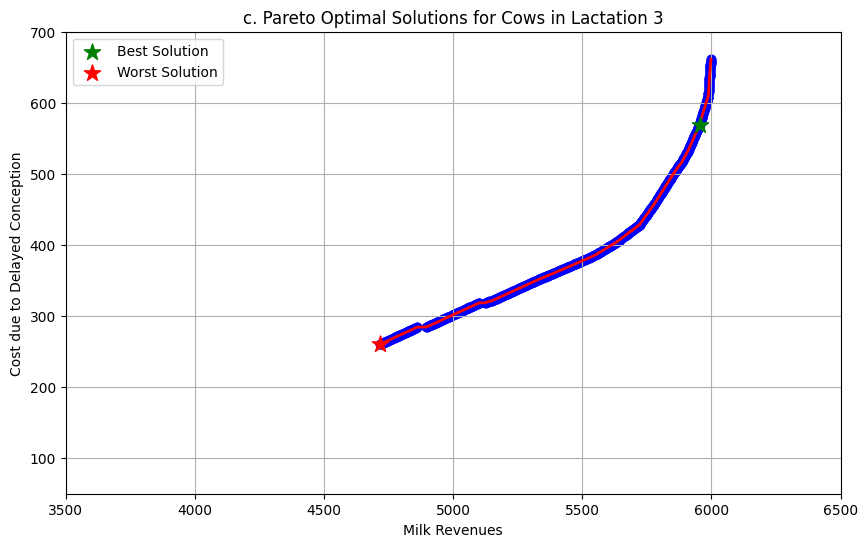

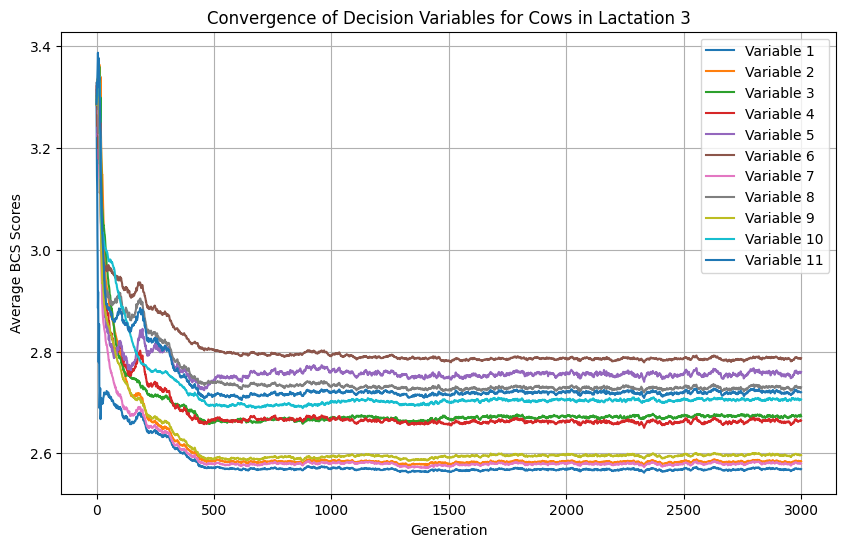

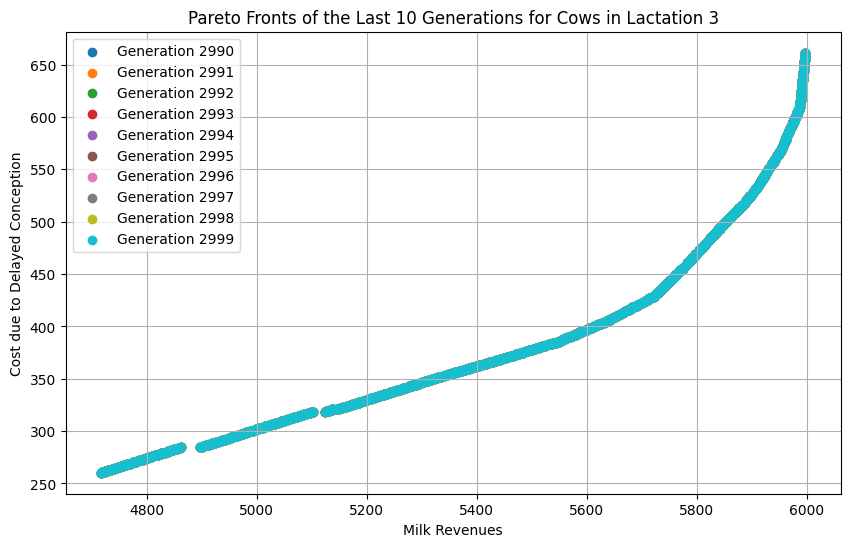

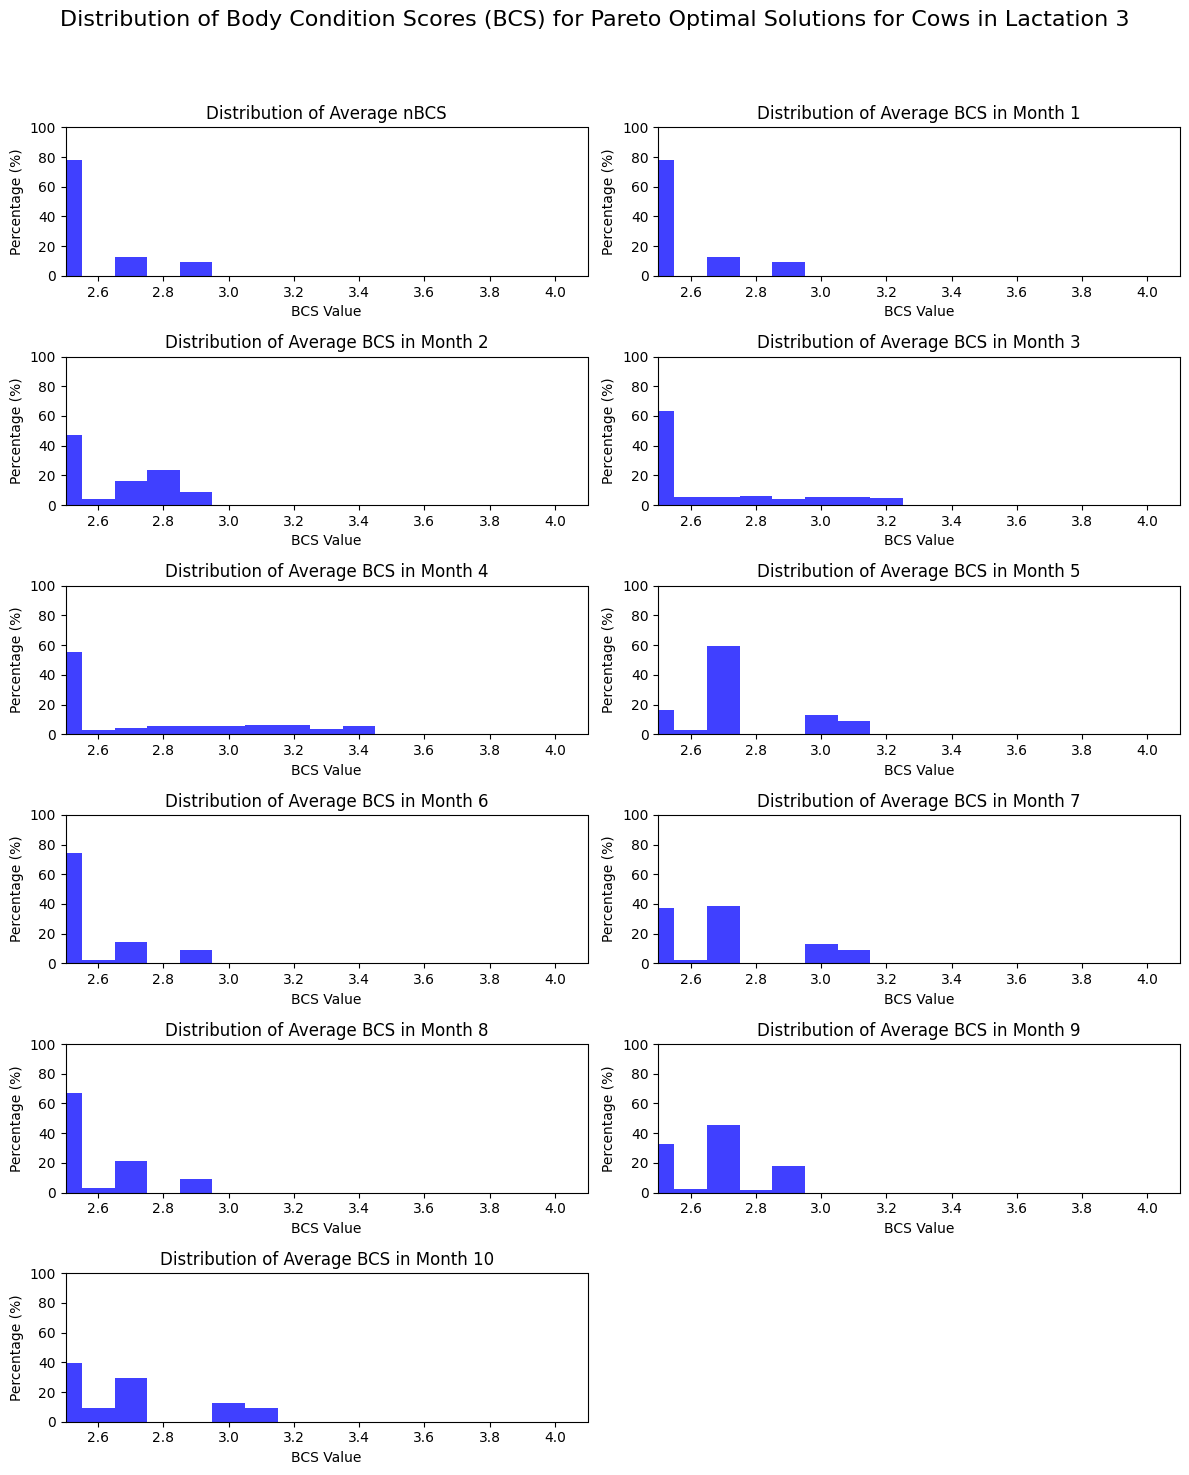

In [4]:
# Lactation 3
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt

# Define the custom problem
class CustomProblem(Problem):

    def __init__(self, weights_conception_DIM):
        super().__init__(n_var=11, n_obj=2, n_constr=0, xl=2.5, xu=4.1)
        self.weights_conception_DIM = weights_conception_DIM

    def calculate_weighted_conception_DIM(self, conception_DIM):
        weights = self.weights_conception_DIM
        weighted_conception_DIM = 0
        days_remaining = conception_DIM
        for i in range(10):
            if days_remaining > 30:
                weighted_conception_DIM += 30 * weights[i]
                days_remaining -= 30
            else:
                weighted_conception_DIM += days_remaining * weights[i]
                break
        return weighted_conception_DIM

    def _evaluate(self, X, out, *args, **kwargs):
        F1 = []
        F2 = []

        for x in X:
            penalty = 0
            for i in range(9):
                if abs(x[1] - x[2]) >= 0.306:
                    penalty += 100000
                if abs(x[2] - x[3]) >= 0.375:
                    penalty += 100000
                if abs(x[3] - x[4]) >= 0.246:
                    penalty += 100000
                if abs(x[4] - x[5]) >= 0.293:
                    penalty += 100000
                if abs(x[5] - x[6]) >= 0.260:
                    penalty += 100000
                if abs(x[6] - x[7]) >= 0.277:
                    penalty += 100000
                if abs(x[7] - x[8]) >= 0.257:
                    penalty += 100000
                if abs(x[8] - x[9]) >= 0.260:
                    penalty += 100000
                if abs(x[9] - x[10]) >= 0.264:
                    penalty += 100000

            # NEW: Ensure x[0] is the minimum among all x[i]
            for i2 in range(1, 11):
                if x[0] > x[i2]:
                    penalty += 100000

            milk_production = (20700.90 - 529.38 * x[0] - 171.36 * x[1] + 884.34 * x[2] - 1095.48 * x[3]
                   - 1084.26 * x[4] - 447.78 * x[5] + 96.594 * x[6] - 544.68 * x[7] + 287.64 * x[8]
                   + 845.58 * x[9] - 785.40 * x[10])

            conception_DIM = (182 - 72.4 * x[0] + 2.40 * x[1] + 39.6 * x[2] - 12.7 * x[3]
                               -13.6 * x[4] - 32.6 * x[5] + 47.4 * x[6] - 21.8 * x[7]
                               + 32.3 * x[8] + 18.2 * x[9] - 13.7 * x[10])

            # Apply penalties
            milk_production -= penalty
            conception_DIM += penalty

            weighted_milk_production = -0.40 * milk_production
            weighted_conception_DIM = self.calculate_weighted_conception_DIM(conception_DIM)

            F1.append(weighted_milk_production)
            F2.append(weighted_conception_DIM)

        out["F"] = np.column_stack([F1, F2])

# Weights for 10 months
weights_conception_DIM = [2.00, 4.13, 5.53, 5.10, 4.50, 3.90, 3.27, 2.60, 1.87, 1.10]
problem = CustomProblem(weights_conception_DIM)

# Set up the NSGA-II algorithm
algorithm = NSGA2(pop_size=1000)

# Callback to store results
class GenerationCallback:
    def __init__(self):
        self.generations = []
        self.decision_vars = []

    def __call__(self, algorithm):
        self.generations.append(algorithm.pop.get("F"))
        self.decision_vars.append(algorithm.pop.get("X"))

callback = GenerationCallback()

# Run the optimization
res = minimize(problem,
               algorithm,
               ('n_gen', 3000),
               seed=204,
               callback=callback,
               verbose=False)

# Final results
print("Final Objective Values:")
print(res.F)
print("\nFinal Decision Variables:")
print(res.X)

# Best and Worst Solutions
last_gen = callback.generations[-1]
last_gen_decision_vars = callback.decision_vars[-1]
objective_values = -last_gen[:, 0] - last_gen[:, 1]
best_index = np.argmax(objective_values)
worst_index = np.argmin(objective_values)

best_solution = last_gen[best_index]
best_decision_vars = last_gen_decision_vars[best_index]
worst_solution = last_gen[worst_index]
worst_decision_vars = last_gen_decision_vars[worst_index]

print("\nBest Solution:")
print("Objective Values:", best_solution)
print("Decision Variables:", best_decision_vars)
print("\nWorst Solution:")
print("Objective Values:", worst_solution)
print("Decision Variables:", worst_decision_vars)

# Plot Pareto Front
plt.figure(figsize=(10, 6))
pareto_front = res.F[np.argsort(res.F[:, 0])]
plt.plot(-pareto_front[:, 0], pareto_front[:, 1], 'r-', lw=2)
plt.scatter(-pareto_front[:, 0], pareto_front[:, 1], c='blue', marker='o')
plt.scatter(-best_solution[0], best_solution[1], c='green', marker='*', s=150, label="Best Solution", zorder=5)
plt.scatter(-worst_solution[0], worst_solution[1], c='red', marker='*', s=150, label="Worst Solution", zorder=5)
plt.xlim(3500, 6500)
plt.ylim(50, 700)
plt.title('c. Pareto Optimal Solutions for Cows in Lactation 3')
plt.xlabel('Milk Revenues')
plt.ylabel('Cost due to Delayed Conception')
plt.legend()
plt.grid(True)
plt.show()

# Plot Decision Variable Convergence
average_decision_vars = np.array([np.mean(gen, axis=0) for gen in callback.decision_vars])
plt.figure(figsize=(10, 6))
for i in range(problem.n_var):
    plt.plot(average_decision_vars[:, i], label=f'Variable {i+1}')
plt.title('Convergence of Decision Variables for Cows in Lactation 3')
plt.xlabel('Generation')
plt.ylabel('Average BCS Scores')
plt.legend()
plt.grid(True)
plt.show()

# Plot Last 10 Generations
last_10_generations = callback.generations[-10:]
plt.figure(figsize=(10, 6))
for i, gen in enumerate(last_10_generations):
    plt.scatter(-gen[:, 0], gen[:, 1], label=f'Generation {len(callback.generations) - 10 + i}')
plt.title('Pareto Fronts of the Last 10 Generations for Cows in Lactation 3')
plt.xlabel('Milk Revenues')
plt.ylabel('Cost due to Delayed Conception')
plt.legend()
plt.grid(True)
plt.show()

# Plot Histograms of Decision Variables
pareto_solutions = res.X
bin_width = 0.1
bins = np.arange(2.5, 4.1 + bin_width, bin_width)
plt.figure(figsize=(12, 15))
for i in range(problem.n_var):
    plt.subplot(6, 2, i + 1)
    counts, bins = np.histogram(pareto_solutions[:, i], bins=bins, density=True)
    percentages = counts * np.diff(bins)[0] * 100
    plt.bar(bins[:-1], percentages, width=bin_width, alpha=0.75, color='blue')
    plt.ylim(0, 100)
    plt.xlim(2.5, 4.1)
    plt.title(f"Distribution of Average BCS in Month {i}" if i > 0 else "Distribution of Average nBCS")
    plt.xlabel('BCS Value')
    plt.ylabel('Percentage (%)')
plt.suptitle('Distribution of Body Condition Scores (BCS) for Pareto Optimal Solutions for Cows in Lactation 3', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


Final Objective Values:
[[-6099.77241111   645.29016034]
 [-4613.92464058   115.36850751]
 [-4822.20042869   139.38248806]
 ...
 [-5633.80016169   318.68277743]
 [-5790.06244354   377.11751798]
 [-5647.4484491    323.6324382 ]]

Final Decision Variables:
[[2.5        3.37274216 3.09698034 ... 2.79600412 2.54504102 2.50000002]
 [2.95936391 2.95942196 3.22533098 ... 2.95966188 3.19092507 2.95974963]
 [2.75618468 2.75657307 3.03225249 ... 2.75635087 2.96586296 2.75701613]
 ...
 [2.5        2.50000007 2.77598854 ... 2.50067961 2.5018835  2.50000004]
 [2.50000001 2.50001748 2.77599518 ... 2.7116666  2.50543399 2.50000013]
 [2.5        2.50000115 2.77595656 ... 2.50347911 2.50222548 2.50000006]]

Best Solution:
Objective Values: [-6016.28596806   498.90880859]
Decision Variables: [2.5        2.82259699 3.0969678  2.71899679 2.50000015 2.77099554
 2.50000072 2.50000613 2.79595976 2.55186669 2.50000284]

Worst Solution:
Objective Values: [-4613.92464058   115.36850751]
Decision Variables: [2.9

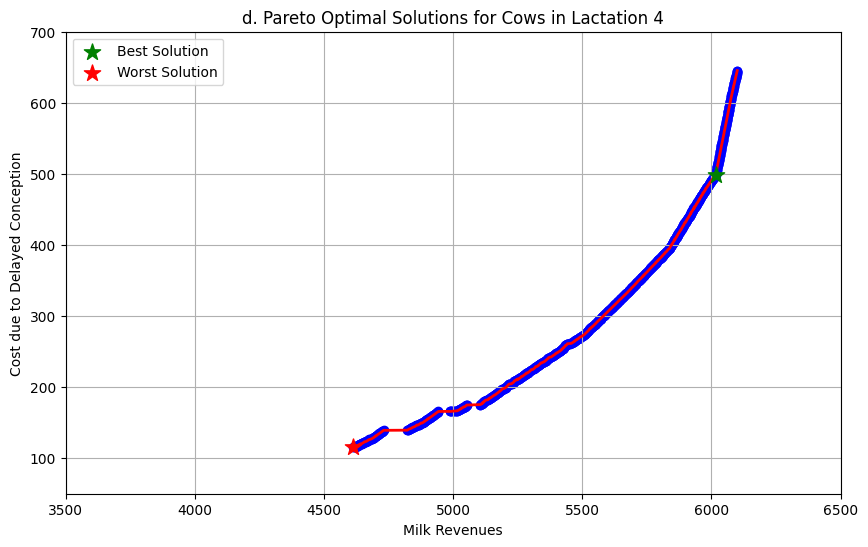

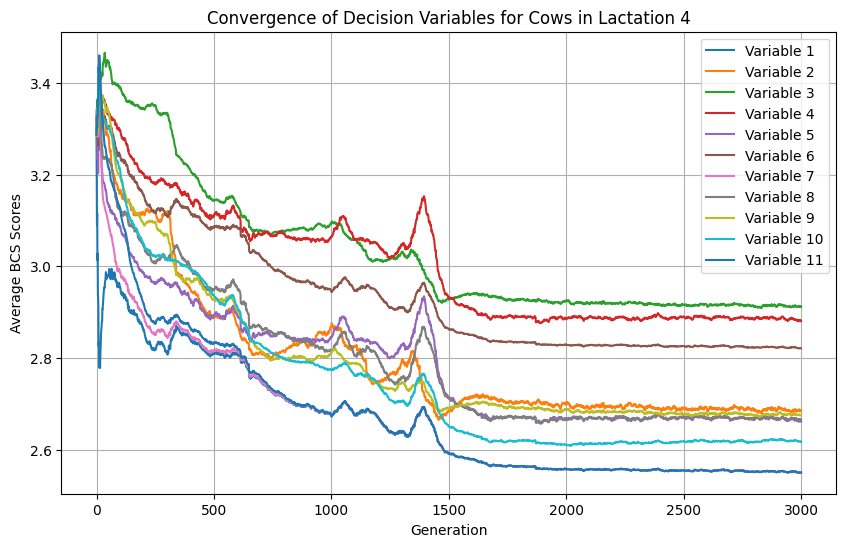

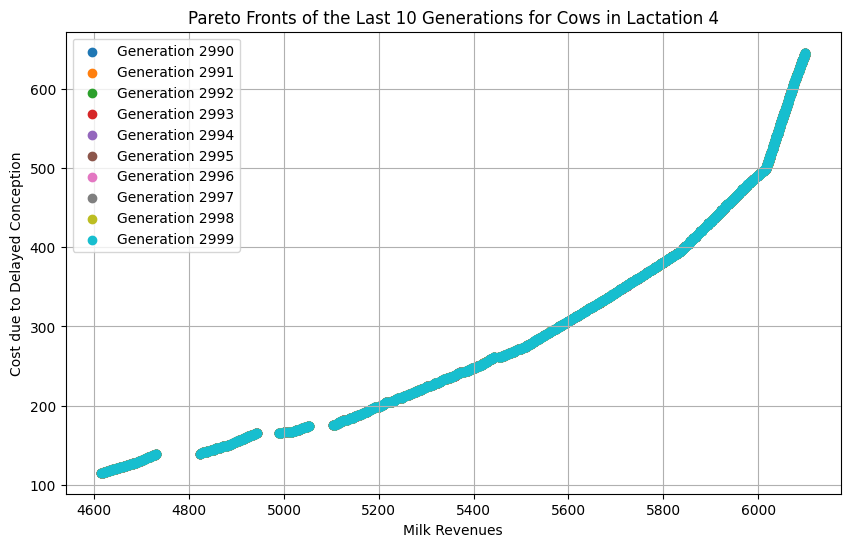

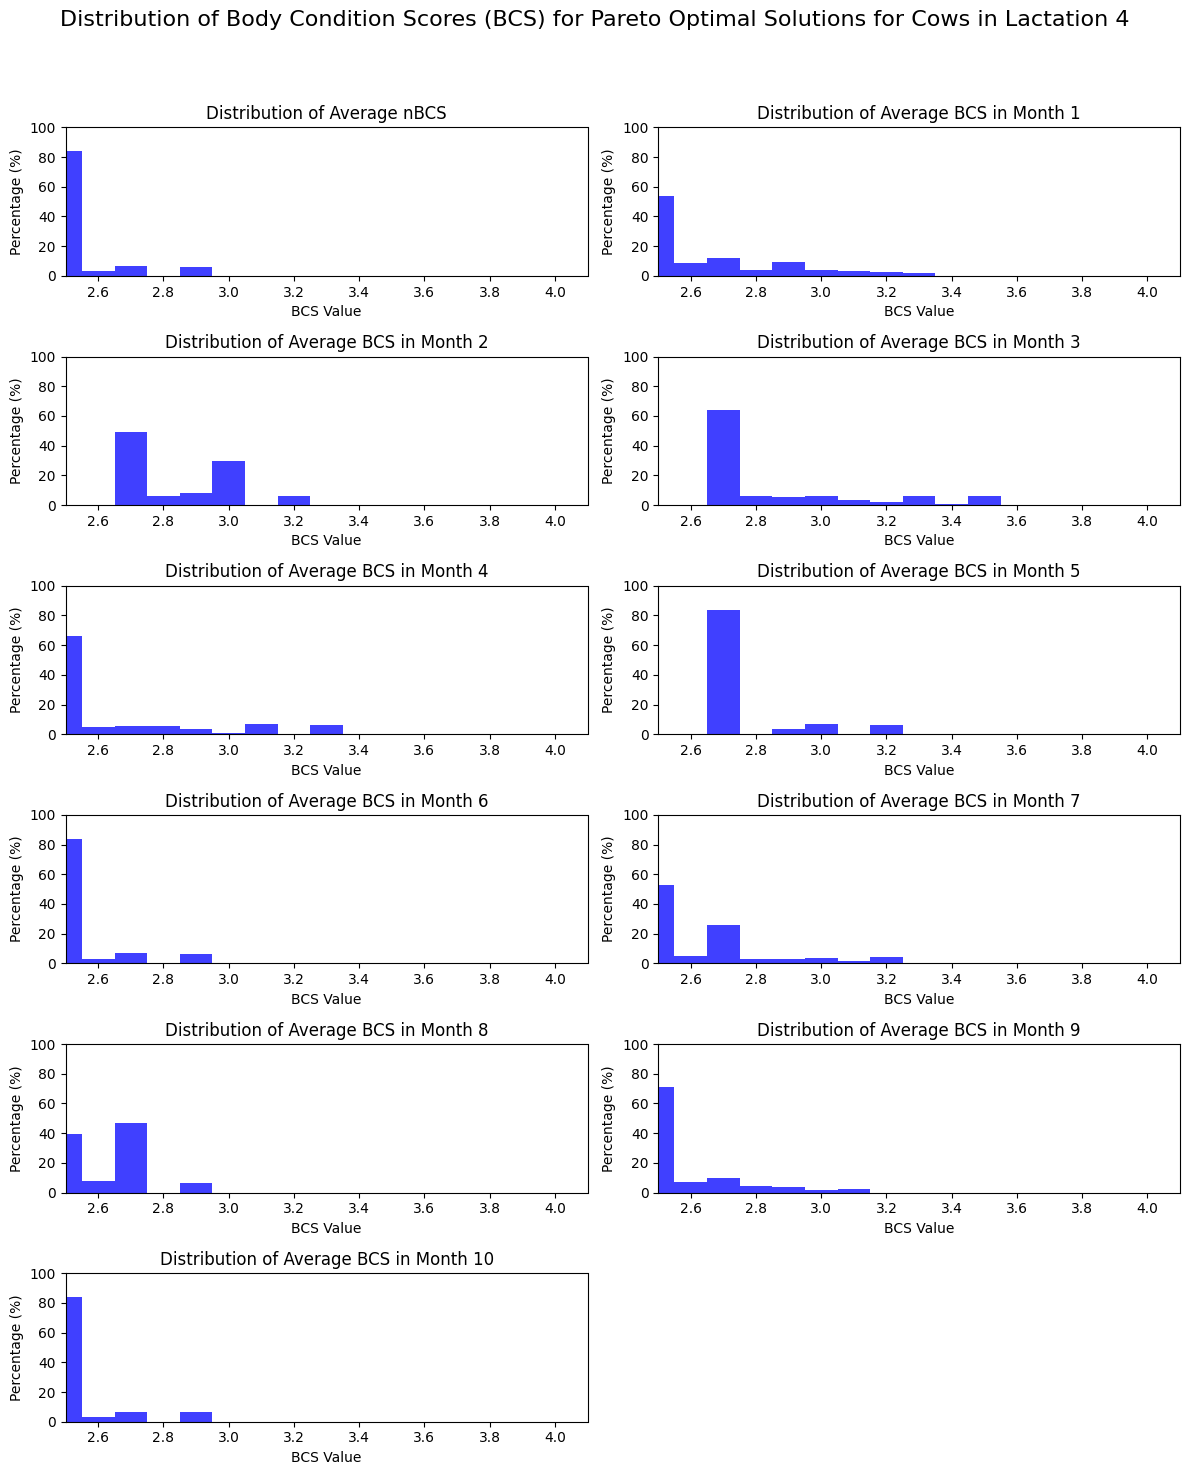

In [5]:
# Lactation 4
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt

# Define the custom problem
class CustomProblem(Problem):

    def __init__(self, weights_conception_DIM):
        super().__init__(n_var=11, n_obj=2, n_constr=0, xl=2.5, xu=4.1)
        self.weights_conception_DIM = weights_conception_DIM

    def calculate_weighted_conception_DIM(self, conception_DIM):
        weights = self.weights_conception_DIM
        weighted_conception_DIM = 0
        days_remaining = conception_DIM
        for i in range(10):
            if days_remaining > 30:
                weighted_conception_DIM += 30 * weights[i]
                days_remaining -= 30
            else:
                weighted_conception_DIM += days_remaining * weights[i]
                break
        return weighted_conception_DIM

    def _evaluate(self, X, out, *args, **kwargs):
        F1 = []
        F2 = []

        for x in X:
            penalty = 0
            for i in range(9):
                if abs(x[1] - x[2]) >= 0.276:
                    penalty += 100000
                if abs(x[2] - x[3]) >= 0.378:
                    penalty += 100000
                if abs(x[3] - x[4]) >= 0.219:
                    penalty += 100000
                if abs(x[4] - x[5]) >= 0.274:
                    penalty += 100000
                if abs(x[5] - x[6]) >= 0.271:
                    penalty += 100000
                if abs(x[6] - x[7]) >= 0.259:
                    penalty += 100000
                if abs(x[7] - x[8]) >= 0.296:
                    penalty += 100000
                if abs(x[8] - x[9]) >= 0.251:
                    penalty += 100000
                if abs(x[9] - x[10]) >= 0.233:
                    penalty += 100000

            # NEW: Ensure x[0] is the minimum among all x[i]
            for i2 in range(1, 11):
                if x[0] > x[i2]:
                    penalty += 100000

            milk_production = (20495.88 - 746.64 * x[0] + 378.42 * x[1] + 1005.72 * x[2] + 319.26 * x[3]
                   - 2665.26 * x[4] + 4.2738 * x[5] - 569.16 * x[6] - 1584.06 * x[7]
                   + 1408.62 * x[8] - 66.096 * x[9] - 149.94 * x[10])

            conception_DIM = (194 - 93.7 * x[0] + 63.0 * x[1] + 3.13 * x[2] - 59.1 * x[3]
                               + 16.3 * x[4] - 37.2 * x[5] + 69.1 * x[6] - 42.0 * x[7]
                               + 43.1 * x[8] - 1.39 * x[9] + 6.15 * x[10])

            milk_production -= penalty
            conception_DIM += penalty

            weighted_milk_production = -0.40 * milk_production
            weighted_conception_DIM = self.calculate_weighted_conception_DIM(conception_DIM)

            F1.append(weighted_milk_production)
            F2.append(weighted_conception_DIM)

        out["F"] = np.column_stack([F1, F2])

# Weights for 10 months
weights_conception_DIM = [1.73, 3.93, 5.37, 4.97, 4.37, 3.80, 3.17, 2.47, 1.77, 0.93]
problem = CustomProblem(weights_conception_DIM)

# Set up the NSGA-II algorithm
algorithm = NSGA2(pop_size=1000)

# Callback to store results
class GenerationCallback:
    def __init__(self):
        self.generations = []
        self.decision_vars = []

    def __call__(self, algorithm):
        self.generations.append(algorithm.pop.get("F"))
        self.decision_vars.append(algorithm.pop.get("X"))

callback = GenerationCallback()

# Run the optimization
res = minimize(problem,
               algorithm,
               ('n_gen', 3000),
               seed=204,
               callback=callback,
               verbose=False)

# Final results
print("Final Objective Values:")
print(res.F)
print("\nFinal Decision Variables:")
print(res.X)

# Best and Worst Solutions
last_gen = callback.generations[-1]
last_gen_decision_vars = callback.decision_vars[-1]
objective_values = -last_gen[:, 0] - last_gen[:, 1]
best_index = np.argmax(objective_values)
worst_index = np.argmin(objective_values)

best_solution = last_gen[best_index]
best_decision_vars = last_gen_decision_vars[best_index]
worst_solution = last_gen[worst_index]
worst_decision_vars = last_gen_decision_vars[worst_index]

print("\nBest Solution:")
print("Objective Values:", best_solution)
print("Decision Variables:", best_decision_vars)
print("\nWorst Solution:")
print("Objective Values:", worst_solution)
print("Decision Variables:", worst_decision_vars)

# Plot Pareto Front
plt.figure(figsize=(10, 6))
pareto_front = res.F[np.argsort(res.F[:, 0])]
plt.plot(-pareto_front[:, 0], pareto_front[:, 1], 'r-', lw=2)
plt.scatter(-pareto_front[:, 0], pareto_front[:, 1], c='blue', marker='o')
plt.scatter(-best_solution[0], best_solution[1], c='green', marker='*', s=150, label="Best Solution", zorder=5)
plt.scatter(-worst_solution[0], worst_solution[1], c='red', marker='*', s=150, label="Worst Solution", zorder=5)
plt.xlim(3500, 6500)
plt.ylim(50, 700)
plt.title('d. Pareto Optimal Solutions for Cows in Lactation 4')
plt.xlabel('Milk Revenues')
plt.ylabel('Cost due to Delayed Conception')
plt.legend()
plt.grid(True)
plt.show()

# Plot Decision Variable Convergence
average_decision_vars = np.array([np.mean(gen, axis=0) for gen in callback.decision_vars])
plt.figure(figsize=(10, 6))
for i in range(problem.n_var):
    plt.plot(average_decision_vars[:, i], label=f'Variable {i+1}')
plt.title('Convergence of Decision Variables for Cows in Lactation 4')
plt.xlabel('Generation')
plt.ylabel('Average BCS Scores')
plt.legend()
plt.grid(True)
plt.show()

# Plot Last 10 Generations
last_10_generations = callback.generations[-10:]
plt.figure(figsize=(10, 6))
for i, gen in enumerate(last_10_generations):
    plt.scatter(-gen[:, 0], gen[:, 1], label=f'Generation {len(callback.generations) - 10 + i}')
plt.title('Pareto Fronts of the Last 10 Generations for Cows in Lactation 4')
plt.xlabel('Milk Revenues')
plt.ylabel('Cost due to Delayed Conception')
plt.legend()
plt.grid(True)
plt.show()

# Plot Histograms of Decision Variables
pareto_solutions = res.X
bin_width = 0.1
bins = np.arange(2.5, 4.1 + bin_width, bin_width)
plt.figure(figsize=(12, 15))
for i in range(problem.n_var):
    plt.subplot(6, 2, i + 1)
    counts, bins = np.histogram(pareto_solutions[:, i], bins=bins, density=True)
    percentages = counts * np.diff(bins)[0] * 100
    plt.bar(bins[:-1], percentages, width=bin_width, alpha=0.75, color='blue')
    plt.ylim(0, 100)
    plt.xlim(2.5, 4.1)
    plt.title(f"Distribution of Average BCS in Month {i}" if i > 0 else "Distribution of Average nBCS")
    plt.xlabel('BCS Value')
    plt.ylabel('Percentage (%)')
plt.suptitle('Distribution of Body Condition Scores (BCS) for Pareto Optimal Solutions for Cows in Lactation 4', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


Final Objective Values:
[[-5909.15919255   566.23839488]
 [-4198.24637081   276.0583378 ]
 [-5890.34697875   526.31544024]
 ...
 [-4222.24706184   277.81914443]
 [-5837.17069165   504.63653316]
 [-4222.16984668   277.77992054]]

Final Decision Variables:
[[2.500002   2.87561343 3.14136587 ... 3.19191728 3.42243298 3.19980338]
 [3.09803586 3.09822913 3.10009784 ... 3.1628257  3.14514374 3.37111733]
 [2.5000002  2.74210709 3.00802416 ... 2.75200029 2.98239518 2.75642686]
 ...
 [3.09493755 3.09495766 3.1044462  ... 3.13023491 3.14376008 3.36960375]
 [2.5        2.74210321 3.00801575 ... 2.75185413 2.98233723 3.01560352]
 [3.09493756 3.09495766 3.10452173 ... 3.1298706  3.14376008 3.36965181]]

Best Solution:
Objective Values (Weighted Milk Production, Weighted Conception DIM):
[-5890.34697875   526.31544024]
Decision Variables:
[2.5000002  2.74210709 3.00802416 2.68705658 2.50000037 2.77396385
 2.76585087 2.50000134 2.75200029 2.98239518 2.75642686]

Worst Solution:
Objective Values (Weig

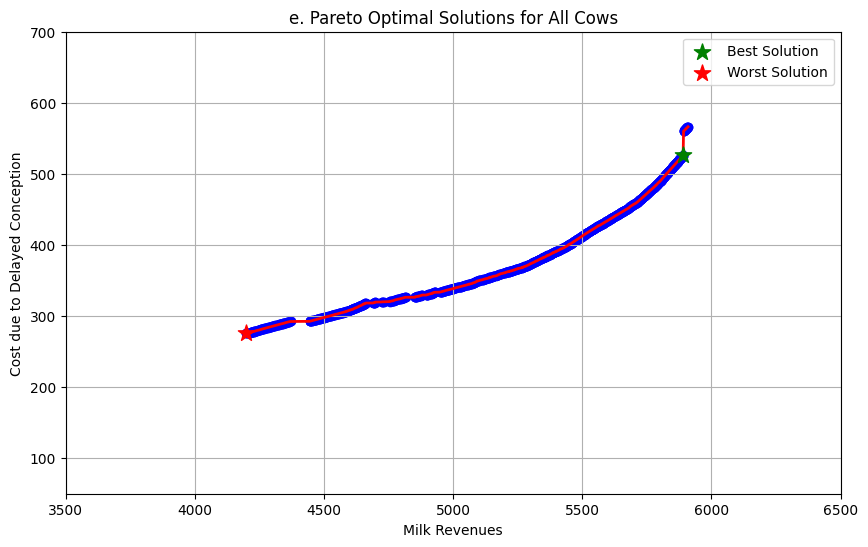

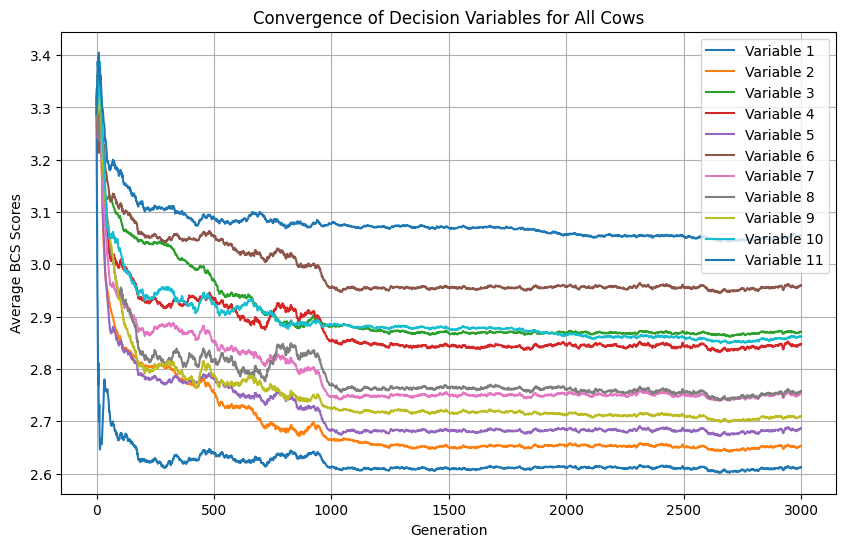

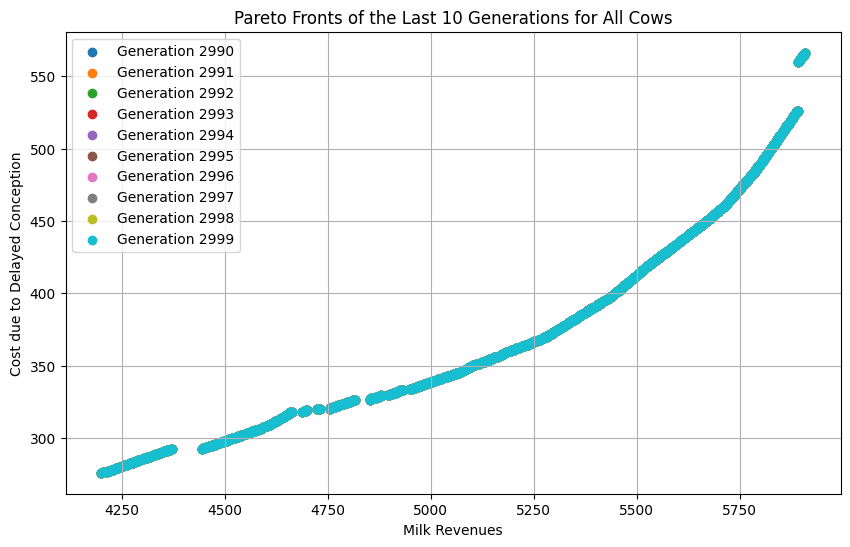

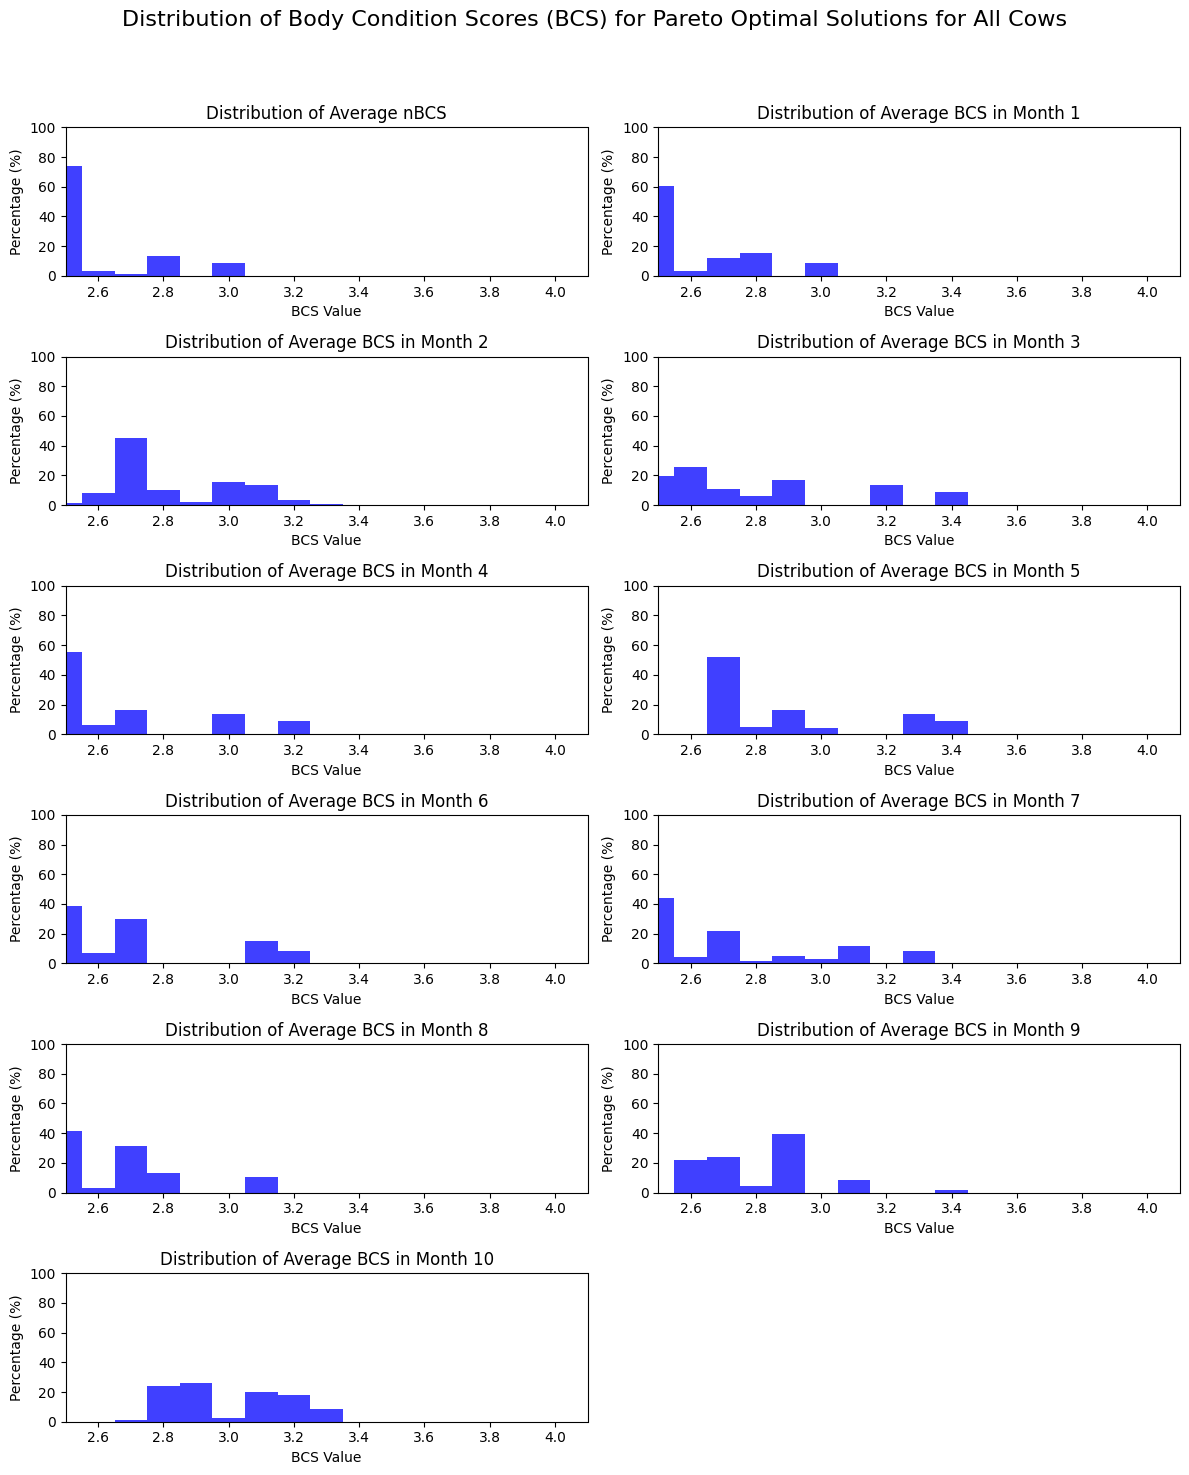

In [6]:
#All Cows
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt

# Define the custom problem
class CustomProblem(Problem):

    def __init__(self, weights_conception_DIM):
        super().__init__(n_var=11, n_obj=2, n_constr=0, xl=2.5, xu=4.1)
        self.weights_conception_DIM = weights_conception_DIM

    def calculate_weighted_conception_DIM(self, conception_DIM):
        weights = self.weights_conception_DIM
        weighted_conception_DIM = 0
        days_remaining = conception_DIM
        for i in range(10):
            if days_remaining > 30:
                weighted_conception_DIM += 30 * weights[i]
                days_remaining -= 30
            else:
                weighted_conception_DIM += days_remaining * weights[i]
                break
        return weighted_conception_DIM

    def _evaluate(self, X, out, *args, **kwargs):
        F1 = []
        F2 = []

        for x in X:
            penalty = 0

            # Existing penalty checks
            # (Though you've put these in a for-loop over i in range(9),
            #  notice you are not using 'i' here, so the same set of checks
            #  effectively runs 9 times. You can keep or remove that loop
            #  depending on your intent. Below is kept as-is.)
            for i in range(9):
                if abs(x[1] - x[2]) >= 0.266:
                    penalty += 100000
                if abs(x[2] - x[3]) >= 0.321:
                    penalty += 100000
                if abs(x[3] - x[4]) >= 0.201:
                    penalty += 100000
                if abs(x[4] - x[5]) >= 0.274:
                    penalty += 100000
                if abs(x[5] - x[6]) >= 0.254:
                    penalty += 100000
                if abs(x[6] - x[7]) >= 0.266:
                    penalty += 100000
                if abs(x[7] - x[8]) >= 0.252:
                    penalty += 100000
                if abs(x[8] - x[9]) >= 0.232:
                    penalty += 100000
                if abs(x[9] - x[10]) >= 0.226:
                    penalty += 100000

            # NEW: Ensure x[0] is the minimum among all x[i].
            # Penalize any violation where x[0] > x[i].
            for i2 in range(1, 11):
                if x[0] > x[i2]:
                    penalty += 100000

            # Your objective calculations
            milk_production = (20924.28 - 2235.84 * x[0] - 390.66 * x[1]
                   + 1795.20 * x[2] - 1228.08 * x[3]
                   - 1957.38 * x[4] + 288.66 * x[5]
                   + 754.80 * x[6] - 1528.98 * x[7]
                   + 835.38 * x[8] + 1101.60 * x[9]
                   - 505.92 * x[10])

            conception_DIM = (182 - 39.7 * x[0] + 17.5 * x[1]
                              + 15.7 * x[2] - 26.6 * x[3]
                              + 12.2 * x[4] - 31.8 * x[5]
                              + 24.4 * x[6] - 24.1 * x[7]
                              + 23.3 * x[8] + 27.9 * x[9]
                              - 20.5 * x[10])

            # Apply penalties
            milk_production -= penalty
            conception_DIM += penalty

            weighted_milk_production = -0.40 * milk_production
            weighted_conception_DIM = self.calculate_weighted_conception_DIM(conception_DIM)

            F1.append(weighted_milk_production)
            F2.append(weighted_conception_DIM)

        out["F"] = np.column_stack([F1, F2])

# Weights for 10 months
weights_conception_DIM = [1.39, 3.34, 4.73, 4.47, 4.04, 3.62, 3.17, 2.67, 2.21, 1.72]
problem = CustomProblem(weights_conception_DIM)

# Set up the NSGA-II algorithm
algorithm = NSGA2(pop_size=1000)

# Callback to store results
class GenerationCallback:

    def __init__(self):
        self.generations = []
        self.decision_vars = []

    def __call__(self, algorithm):
        self.generations.append(algorithm.pop.get("F"))
        self.decision_vars.append(algorithm.pop.get("X"))

# Initialize callback
callback = GenerationCallback()

# Run the optimization
res = minimize(problem,
               algorithm,
               ('n_gen', 3000),  # Increased number of generations
               seed=204,
               callback=callback,
               verbose=False)

# Final results
print("Final Objective Values:")
print(res.F)
print()

print("Final Decision Variables:")
print(res.X)
print()

# Find the best solution from the last generation
last_gen = callback.generations[-1]
last_gen_decision_vars = callback.decision_vars[-1]

# Change weighted milk production to positive and subtract weighted conception DIM
objective_values = -last_gen[:, 0] - last_gen[:, 1]
best_index = np.argmax(objective_values)
best_solution = last_gen[best_index]
best_decision_vars = last_gen_decision_vars[best_index]

print("Best Solution:")
print("Objective Values (Weighted Milk Production, Weighted Conception DIM):")
print(best_solution)
print("Decision Variables:")
print(best_decision_vars)
print()

# Find the worst solution from the last generation
worst_index = np.argmin(objective_values)
worst_solution = last_gen[worst_index]
worst_decision_vars = last_gen_decision_vars[worst_index]

print("Worst Solution:")
print("Objective Values (Weighted Milk Production, Weighted Conception DIM):")
print(worst_solution)
print("Decision Variables:")
print(worst_decision_vars)
print()

# Plot Pareto front with line, highlighting best and worst solutions
plt.figure(figsize=(10, 6))

# Plot all Pareto front solutions with a red line
pareto_front = res.F[np.argsort(res.F[:, 0])]
plt.plot(-pareto_front[:, 0], pareto_front[:, 1], 'r-', lw=2)  # Changed sign for plotting

# Plot all solutions in blue
plt.scatter(-pareto_front[:, 0], pareto_front[:, 1], c='blue', marker='o')  # Changed sign for plotting

# Highlight the best solution with a green star
plt.scatter(-best_solution[0], best_solution[1], c='green', marker='*', s=150, label="Best Solution", zorder=5)

# Highlight the worst solution with a red star
plt.scatter(-worst_solution[0], worst_solution[1], c='red', marker='*', s=150, label="Worst Solution", zorder=5)

# Set axis limits
plt.xlim(3500, 6500)
plt.ylim(50, 700)

plt.title('e. Pareto Optimal Solutions for All Cows')
plt.xlabel('Milk Revenues')
plt.ylabel('Cost due to Delayed Conception')
plt.legend()
plt.grid(True)
plt.show()

# Plot convergence of decision variables
average_decision_vars = np.array([np.mean(gen, axis=0) for gen in callback.decision_vars])

plt.figure(figsize=(10, 6))
for i in range(problem.n_var):
    plt.plot(average_decision_vars[:, i], label=f'Variable {i+1}')
plt.title('Convergence of Decision Variables for All Cows')
plt.xlabel('Generation')
plt.ylabel('Average BCS Scores')
plt.legend()
plt.grid(True)
plt.show()

# Plot Pareto fronts of the last 10 generations
last_10_generations = callback.generations[-10:]
plt.figure(figsize=(10, 6))
for i, gen in enumerate(last_10_generations):
    plt.scatter(-gen[:, 0], gen[:, 1], label=f'Generation {len(callback.generations) - 10 + i}')
plt.title('Pareto Fronts of the Last 10 Generations for All Cows')
plt.xlabel('Milk Revenues')
plt.ylabel('Cost due to Delayed Conception')
plt.legend()
plt.grid(True)
plt.show()

# Plot histogram of Pareto optimal solutions with percentage on y-axis
pareto_solutions = res.X  # These are the decision variables of the Pareto front solutions
n_vars = problem.n_var

# Define the bin size
bin_width = 0.1
bins = np.arange(2.5, 4.1 + bin_width, bin_width)  # Set bins from 2.5 to 4.1 with 0.1 intervals

# Plot histograms of Pareto optimal solutions for each decision variable
plt.figure(figsize=(12, 15))

for i in range(n_vars):
    plt.subplot(6, 2, i + 1)

    # Create histogram data
    counts, bins = np.histogram(pareto_solutions[:, i], bins=bins, density=True)

    # Convert to percentage
    percentages = counts * np.diff(bins)[0] * 100

    # Plot the histogram using percentage on y-axis
    plt.bar(bins[:-1], percentages, width=bin_width, alpha=0.75, color='blue')

    plt.ylim(0, 100)
    plt.xlim(2.5, 4.1)
    if i == 0:
        plt.title("Distribution of Average nBCS")
    else:
        plt.title(f"Distribution of Average BCS in Month {i}")
    plt.xlabel('BCS Value')
    plt.ylabel('Percentage (%)')

plt.suptitle('Distribution of Body Condition Scores (BCS) for Pareto Optimal Solutions for All Cows', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


Final Objective Values:
[[-4584.61447169   244.90516061]
 [-5970.28910047   504.50378168]
 [-4840.24022712   279.61773438]
 ...
 [-5737.09705152   409.87745598]
 [-5696.09786807   398.58321859]
 [-4791.46670641   270.35231868]]

Final Decision Variables:
[[2.99430743 2.99438215 2.99439787 ... 3.0090502  2.99434166 3.22908403]
 [2.50000001 2.60444549 2.88614781 ... 2.75740602 2.82507623 2.59186195]
 [2.99430768 2.99437758 3.16570362 ... 3.00953237 2.99434305 3.20933384]
 ...
 [2.50000074 2.50001414 2.78197674 ... 2.50251806 2.50921975 2.50006357]
 [2.50000672 2.50003585 2.78194191 ... 2.51509617 2.50011371 2.50032677]
 [2.99430793 2.99438344 3.09969527 ... 3.00949313 2.9943443  3.22371103]]

Best Solution:
Objective Values: [-5962.83302738   494.43223651]
Decision Variables: [2.50000158 2.57838739 2.85888567 2.51342204 2.50001507 2.7652469
 2.50724862 2.50025972 2.75596254 2.7329574  2.50003583]

Worst Solution:
Objective Values: [-4584.61447169   244.90516061]
Decision Variables: [2.99

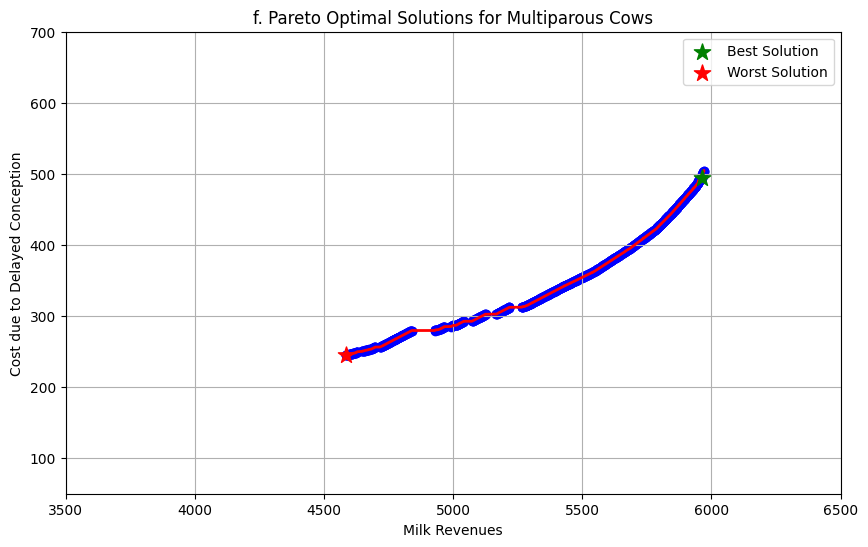

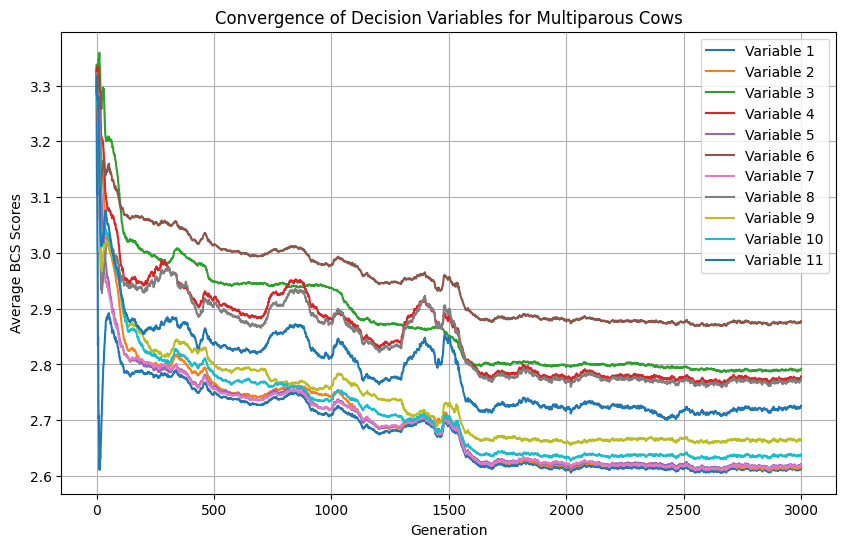

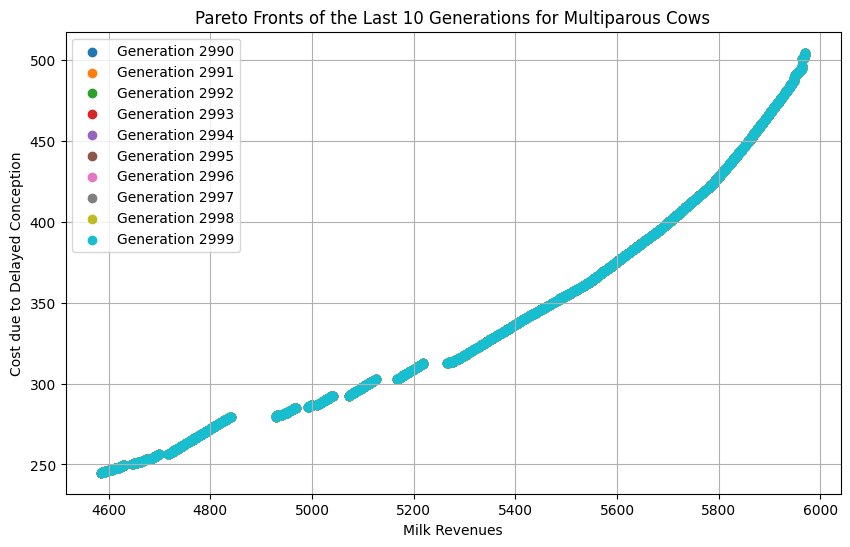

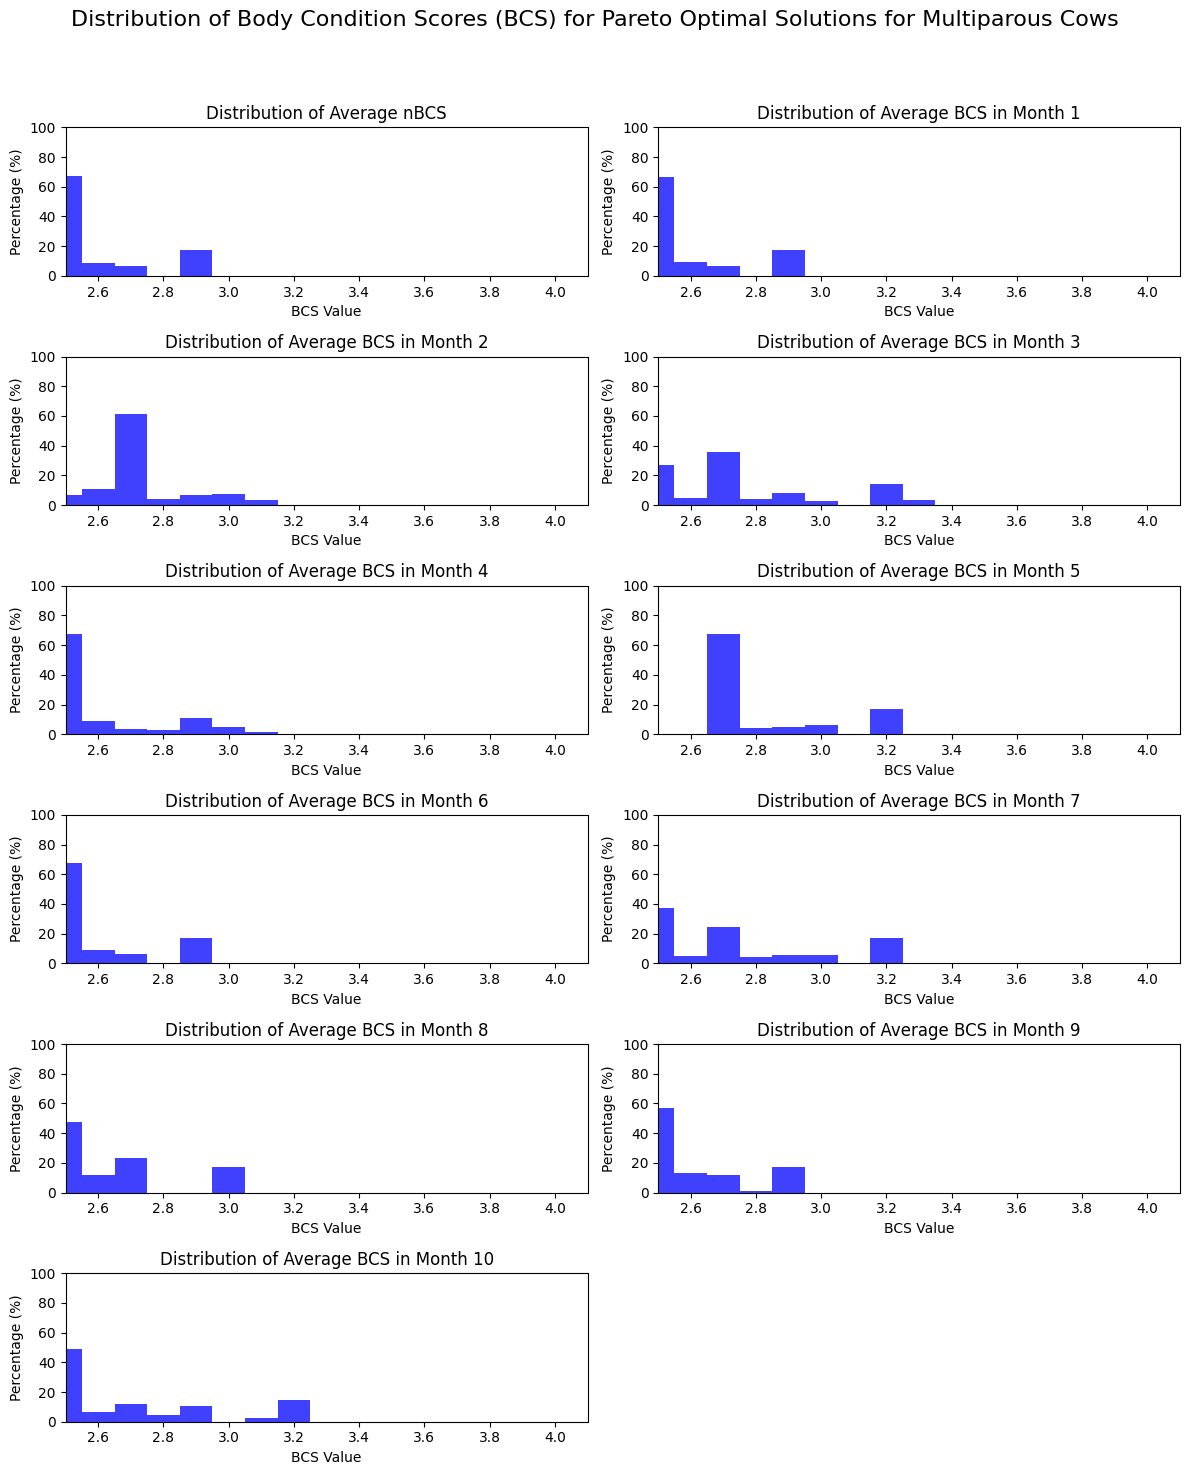

In [7]:
# Multiparous
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt

# Define the custom problem
class CustomProblem(Problem):

    def __init__(self, weights_conception_DIM):
        super().__init__(n_var=11, n_obj=2, n_constr=0, xl=2.5, xu=4.1)
        self.weights_conception_DIM = weights_conception_DIM

    def calculate_weighted_conception_DIM(self, conception_DIM):
        weights = self.weights_conception_DIM
        weighted_conception_DIM = 0
        days_remaining = conception_DIM
        for i in range(10):
            if days_remaining > 30:
                weighted_conception_DIM += 30 * weights[i]
                days_remaining -= 30
            else:
                weighted_conception_DIM += days_remaining * weights[i]
                break
        return weighted_conception_DIM

    def _evaluate(self, X, out, *args, **kwargs):
        F1 = []
        F2 = []

        for x in X:
            penalty = 0
            for i in range(9):
                if abs(x[1] - x[2]) >= 0.282:
                    penalty += 100000
                if abs(x[2] - x[3]) >= 0.346:
                    penalty += 100000
                if abs(x[3] - x[4]) >= 0.217:
                    penalty += 100000
                if abs(x[4] - x[5]) >= 0.279:
                    penalty += 100000
                if abs(x[5] - x[6]) >= 0.258:
                    penalty += 100000
                if abs(x[6] - x[7]) >= 0.272:
                    penalty += 100000
                if abs(x[7] - x[8]) >= 0.257:
                    penalty += 100000
                if abs(x[8] - x[9]) >= 0.237:
                    penalty += 100000
                if abs(x[9] - x[10]) >= 0.235:
                    penalty += 100000

            # NEW: Ensure x[0] is the minimum among all x[i]
            for i2 in range(1, 11):
                if x[0] > x[i2]:
                    penalty += 100000

            milk_production = (21075.24 - 678.30 * x[0] - 584.46 * x[1] + 1684.02 * x[2] - 1138.32 * x[3]
                   - 1499.40 * x[4] + 105.06 * x[5] - 162.18 * x[6] - 1382.10 * x[7]
                   + 619.14 * x[8] + 926.16 * x[9] - 734.40 * x[10])

            conception_DIM = (164 - 71.4 * x[0] + 15.8 * x[1] + 23.9 * x[2] - 25.1 * x[3]
                               + 7.78 * x[4] - 40.5 * x[5] + 55.3 * x[6] - 26.3 * x[7]
                               + 18.5 * x[8] + 31.0 * x[9] - 10.6 * x[10])

            milk_production -= penalty
            conception_DIM += penalty

            weighted_milk_production = -0.40 * milk_production
            weighted_conception_DIM = self.calculate_weighted_conception_DIM(conception_DIM)

            F1.append(weighted_milk_production)
            F2.append(weighted_conception_DIM)

        out["F"] = np.column_stack([F1, F2])

# Weights for 10 months
weights_conception_DIM = [2.04, 4.02, 5.34, 4.93, 4.37, 3.82, 3.23, 2.59, 1.94, 1.23]
problem = CustomProblem(weights_conception_DIM)

# Set up the NSGA-II algorithm
algorithm = NSGA2(pop_size=1000)

# Callback to store results
class GenerationCallback:
    def __init__(self):
        self.generations = []
        self.decision_vars = []

    def __call__(self, algorithm):
        self.generations.append(algorithm.pop.get("F"))
        self.decision_vars.append(algorithm.pop.get("X"))

callback = GenerationCallback()

# Run the optimization
res = minimize(problem,
               algorithm,
               ('n_gen', 3000),
               seed=204,
               callback=callback,
               verbose=False)

# Final results
print("Final Objective Values:")
print(res.F)
print("\nFinal Decision Variables:")
print(res.X)

# Best and Worst Solutions
last_gen = callback.generations[-1]
last_gen_decision_vars = callback.decision_vars[-1]
objective_values = -last_gen[:, 0] - last_gen[:, 1]
best_index = np.argmax(objective_values)
worst_index = np.argmin(objective_values)

best_solution = last_gen[best_index]
best_decision_vars = last_gen_decision_vars[best_index]
worst_solution = last_gen[worst_index]
worse_decision_vars = last_gen_decision_vars[worst_index]

print("\nBest Solution:")
print("Objective Values:", best_solution)
print("Decision Variables:", best_decision_vars)
print("\nWorst Solution:")
print("Objective Values:", worst_solution)
print("Decision Variables:", worse_decision_vars)

# Plot Pareto Front
plt.figure(figsize=(10, 6))
pareto_front = res.F[np.argsort(res.F[:, 0])]
plt.plot(-pareto_front[:, 0], pareto_front[:, 1], 'r-', lw=2)
plt.scatter(-pareto_front[:, 0], pareto_front[:, 1], c='blue', marker='o')
plt.scatter(-best_solution[0], best_solution[1], c='green', marker='*', s=150, label="Best Solution", zorder=5)
plt.scatter(-worst_solution[0], worst_solution[1], c='red', marker='*', s=150, label="Worst Solution", zorder=5)
plt.xlim(3500, 6500)
plt.ylim(50, 700)
plt.title('f. Pareto Optimal Solutions for Multiparous Cows')
plt.xlabel('Milk Revenues')
plt.ylabel('Cost due to Delayed Conception')
plt.legend()
plt.grid(True)
plt.show()

# Plot Decision Variable Convergence
average_decision_vars = np.array([np.mean(gen, axis=0) for gen in callback.decision_vars])
plt.figure(figsize=(10, 6))
for i in range(problem.n_var):
    plt.plot(average_decision_vars[:, i], label=f'Variable {i+1}')
plt.title('Convergence of Decision Variables for Multiparous Cows')
plt.xlabel('Generation')
plt.ylabel('Average BCS Scores')
plt.legend()
plt.grid(True)
plt.show()

# Plot Last 10 Generations
last_10_generations = callback.generations[-10:]
plt.figure(figsize=(10, 6))
for i, gen in enumerate(last_10_generations):
    plt.scatter(-gen[:, 0], gen[:, 1], label=f'Generation {len(callback.generations) - 10 + i}')
plt.title('Pareto Fronts of the Last 10 Generations for Multiparous Cows')
plt.xlabel('Milk Revenues')
plt.ylabel('Cost due to Delayed Conception')
plt.legend()
plt.grid(True)
plt.show()

# Plot Histograms of Decision Variables
pareto_solutions = res.X
bin_width = 0.1
bins = np.arange(2.5, 4.1 + bin_width, bin_width)
plt.figure(figsize=(12, 15))
for i in range(problem.n_var):
    plt.subplot(6, 2, i + 1)
    counts, bins = np.histogram(pareto_solutions[:, i], bins=bins, density=True)
    percentages = counts * np.diff(bins)[0] * 100
    plt.bar(bins[:-1], percentages, width=bin_width, alpha=0.75, color='blue')
    plt.ylim(0, 100)
    plt.xlim(2.5, 4.1)
    plt.title(f"Distribution of Average BCS in Month {i}" if i > 0 else "Distribution of Average nBCS")
    plt.xlabel('BCS Value')
    plt.ylabel('Percentage (%)')
plt.suptitle('Distribution of Body Condition Scores (BCS) for Pareto Optimal Solutions for Multiparous Cows', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()